In [1]:
# Cell 0 — Minimize JAX GPU allocator overhead
#
# MUST execute before importing JAX.

import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

print(
    "PREALLOCATE:",
    os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"],
)

print(
    "ALLOCATOR:",
    os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"],
)

PREALLOCATE: false
ALLOCATOR: platform


In [2]:
import os
import jax

print(
    "preallocate:",
    os.environ.get("XLA_PYTHON_CLIENT_PREALLOCATE"),
)

print("devices:", jax.devices())

preallocate: false
devices: [CudaDevice(id=0)]


In [3]:
# Cell 1 — Audit the local OpenPI implementation
#
# Goal:
# Verify exactly which OpenPI source/version we are running before
# constructing our π0.5-style FAST pretraining pipeline.

import inspect
import subprocess

import jax

from openpi.models import pi0_config
from openpi.models import pi0_fast
from openpi.training import config as train_config
from openpi.training import weight_loaders

from lerobot.common.datasets.lerobot_dataset import LeRobotDataset


def git(*args):
    return subprocess.check_output(
        ["git", *args],
        text=True,
    ).strip()


print("========== OPENPI CHECKOUT ==========")
print("branch:", git("branch", "--show-current"))
print("commit:", git("rev-parse", "--short", "HEAD"))

print("\n========== JAX ==========")
print("devices:", jax.devices())


print("\n========== EXISTING OPENPI CONFIGS ==========")

for name in [
    "pi0_fast_libero",
    "pi05_libero",
    "pi05_aloha_pen_uncap",
]:
    cfg = train_config.get_config(name)

    print(f"\n{name}")
    print("  model config:", type(cfg.model).__name__)
    print("  model type:", cfg.model.model_type)
    print("  action dim:", cfg.model.action_dim)
    print("  action horizon:", cfg.model.action_horizon)
    print("  weight loader:", type(cfg.weight_loader).__name__)

    if hasattr(cfg.data, "repo_id"):
        print("  dataset:", cfg.data.repo_id)


print("\n========== SOURCE FILES ==========")

print(
    "Pi0FAST:",
    inspect.getsourcefile(pi0_fast.Pi0FAST),
)

print(
    "Pi0Config:",
    inspect.getsourcefile(pi0_config.Pi0Config),
)

print(
    "PaliGemmaWeightLoader:",
    inspect.getsourcefile(weight_loaders.PaliGemmaWeightLoader),
)


print("\n========== LEROBOT DATASET API ==========")

print(
    "LeRobotDataset signature:",
    inspect.signature(LeRobotDataset),
)

========== OPENPI CHECKOUT ==========
branch: pi05-libero-study
commit: 23a1750

========== JAX ==========
devices: [CudaDevice(id=0)]

========== EXISTING OPENPI CONFIGS ==========

pi0_fast_libero
  model config: Pi0FASTConfig
  model type: ModelType.PI0_FAST
  action dim: 7
  action horizon: 10
  weight loader: CheckpointWeightLoader
  dataset: physical-intelligence/libero

pi05_libero
  model config: Pi0Config
  model type: ModelType.PI05
  action dim: 32
  action horizon: 10
  weight loader: CheckpointWeightLoader
  dataset: physical-intelligence/libero

pi05_aloha_pen_uncap
  model config: Pi0Config
  model type: ModelType.PI05
  action dim: 32
  action horizon: 50
  weight loader: CheckpointWeightLoader
  dataset: physical-intelligence/aloha_pen_uncap_diverse

========== SOURCE FILES ==========
Pi0FAST: /home/osx/openpi/src/openpi/models/pi0_fast.py
Pi0Config: /home/osx/openpi/src/openpi/models/pi0_config.py
PaliGemmaWeightLoader: /home/osx/openpi/src/openpi/training/weight_load

In [4]:
# Cell 2 — Load a tiny subset of real ALOHA robot data
#
# Goal:
# Inspect the raw data before applying any OpenPI preprocessing.

import numpy as np

from lerobot.common.datasets.lerobot_dataset import LeRobotDataset


REPO_ID = "lerobot/aloha_static_screw_driver"

# Only two episodes for now.
# The complete dataset contains 50 episodes.
dataset = LeRobotDataset(
    repo_id=REPO_ID,
    episodes=[0, 1],
)

print("========== DATASET ==========")
print("repo:", REPO_ID)
print("selected episodes:", [0, 1])
print("number of frames loaded:", len(dataset))

print("\n========== METADATA ==========")
print("fps:", dataset.meta.fps)
print("tasks:", dataset.meta.tasks)

print("\n========== RAW EXAMPLE ==========")

example = dataset[0]

print("keys:")
for key in example.keys():
    print(" ", key)

print("\n========== IMPORTANT FIELDS ==========")

for key in [
    "observation.state",
    "action",
    "observation.images.cam_high",
    "observation.images.cam_low",
    "observation.images.cam_left_wrist",
    "observation.images.cam_right_wrist",
    "episode_index",
    "frame_index",
    "timestamp",
    "task_index",
]:
    value = example[key]

    print(f"\n{key}")
    print("  type:", type(value))

    if hasattr(value, "shape"):
        print("  shape:", tuple(value.shape))

    if hasattr(value, "dtype"):
        print("  dtype:", value.dtype)

    if key.startswith("observation.images"):
        arr = np.asarray(value)
        print("  min:", arr.min())
        print("  max:", arr.max())

========== DATASET ==========
repo: lerobot/aloha_static_screw_driver
selected episodes: [0, 1]
number of frames loaded: 800

========== METADATA ==========
fps: 50
tasks: {0: 'Pick up the screwdriver with the right arm, hand it over to the left arm then place it into the cup.'}

========== RAW EXAMPLE ==========
keys:
  observation.images.cam_high
  observation.images.cam_left_wrist
  observation.images.cam_low
  observation.images.cam_right_wrist
  observation.state
  observation.effort
  action
  episode_index
  frame_index
  timestamp
  next.done
  index
  task_index
  task

========== IMPORTANT FIELDS ==========

observation.state
  type: <class 'torch.Tensor'>
  shape: (14,)
  dtype: torch.float32

action
  type: <class 'torch.Tensor'>
  shape: (14,)
  dtype: torch.float32

observation.images.cam_high
  type: <class 'torch.Tensor'>
  shape: (3, 480, 640)
  dtype: torch.float32
  min: 0.0
  max: 1.0

observation.images.cam_low
  type: <class 'torch.Tensor'>
  shape: (3, 480, 640)


In [5]:
# Cell 3 — Construct the action chunk exactly as OpenPI does
#
# Goal:
# Turn the per-frame action (14,) into the 50-step action
# chunk (H, D) that will later be normalized and FAST-tokenized.

import numpy as np

from lerobot.common.datasets.lerobot_dataset import (
    LeRobotDataset,
    LeRobotDatasetMetadata,
)


REPO_ID = "lerobot/aloha_static_screw_driver"

ACTION_HORIZON = 50


# Read dataset metadata so we use the dataset's real control frequency.
meta = LeRobotDatasetMetadata(REPO_ID)

fps = meta.fps

print("========== ACTION CHUNK SETTINGS ==========")
print("fps:", fps)
print("action horizon:", ACTION_HORIZON)
print("chunk duration:", ACTION_HORIZON / fps, "seconds")


# This is exactly the idea used by OpenPI's create_torch_dataset().
action_delta_timestamps = [
    t / fps
    for t in range(ACTION_HORIZON)
]

print("\nfirst 5 action timestamps:")
print(action_delta_timestamps[:5])

print("\nlast action timestamp:")
print(action_delta_timestamps[-1])


# Ask LeRobot to return 50 consecutive action samples
# for every observation.
chunked_dataset = LeRobotDataset(
    repo_id=REPO_ID,
    episodes=[0, 1],
    delta_timestamps={
        "action": action_delta_timestamps,
    },
)


sample = chunked_dataset[0]

state = np.asarray(sample["observation.state"])
actions = np.asarray(sample["action"])


print("\n========== CHUNKED SAMPLE ==========")

print("state shape:", state.shape)
print("actions shape:", actions.shape)

print("\ncurrent frame index:", int(sample["frame_index"]))
print("current episode:", int(sample["episode_index"]))

print("\nfirst action:")
print(actions[0])

print("\nlast action in chunk:")
print(actions[-1])

========== ACTION CHUNK SETTINGS ==========
fps: 50
action horizon: 50
chunk duration: 1.0 seconds

first 5 action timestamps:
[0.0, 0.02, 0.04, 0.06, 0.08]

last action timestamp:
0.98

========== CHUNKED SAMPLE ==========
state shape: (14,)
actions shape: (50, 14)

current frame index: 0
current episode: 0

first action:
[ 0.02454369 -0.95567006  1.1750293  -0.00153398 -0.30526218 -0.00153398
  0.16233003 -0.00613592 -0.95567006  1.1658255   0.00153398 -0.2960583
  0.00306796  0.12369067]

last action in chunk:
[ 0.02454369 -0.95567006  1.198039    0.         -0.30679616  0.00920388
  0.08041464  0.11351458 -0.07669904  0.6718836   0.0322136   0.3282719
  0.14266022  0.64918536]


In [6]:
# Cell 4 — Understand the physical action dimensions and verify chunk timing
#
# Goal:
# 1. Label the 14 ALOHA action dimensions.
# 2. Verify that chunked action[k] really corresponds to action at frame t+k.
# 3. Inspect what happens near an episode boundary.

import numpy as np


ACTION_LABELS = [
    "left_joint_1",
    "left_joint_2",
    "left_joint_3",
    "left_joint_4",
    "left_joint_5",
    "left_joint_6",
    "left_gripper",
    "right_joint_1",
    "right_joint_2",
    "right_joint_3",
    "right_joint_4",
    "right_joint_5",
    "right_joint_6",
    "right_gripper",
]


# ------------------------------------------------------------
# Part 1 — inspect the first and last action with labels
# ------------------------------------------------------------

sample = chunked_dataset[0]
actions = np.asarray(sample["action"])

print("========== ACTION DIMENSIONS ==========")

for i, name in enumerate(ACTION_LABELS):
    print(
        f"{i:2d}  {name:16s} "
        f"first={actions[0, i]: .6f}  "
        f"last={actions[-1, i]: .6f}  "
        f"change={actions[-1, i] - actions[0, i]: .6f}"
    )


# ------------------------------------------------------------
# Part 2 — prove that action[k] is really frame t+k
# ------------------------------------------------------------

raw_frame_0 = dataset[0]
raw_frame_49 = dataset[49]

raw_action_0 = np.asarray(raw_frame_0["action"])
raw_action_49 = np.asarray(raw_frame_49["action"])

print("\n========== TEMPORAL VERIFICATION ==========")

print(
    "chunk action[0] == raw frame 0:",
    np.allclose(actions[0], raw_action_0),
)

print(
    "chunk action[49] == raw frame 49:",
    np.allclose(actions[49], raw_action_49),
)

print("\nmax difference at t:")
print(np.max(np.abs(actions[0] - raw_action_0)))

print("max difference at t+49:")
print(np.max(np.abs(actions[49] - raw_action_49)))


# ------------------------------------------------------------
# Part 3 — inspect behavior near the end of episode 0
# ------------------------------------------------------------

# Episode 0 contains 400 frames:
# frame indices 0 ... 399.
#
# Starting at dataset index 390 means a 50-action request would
# conceptually ask for frames 390 ... 439, which crosses the
# episode boundary.

boundary_sample = chunked_dataset[390]
boundary_actions = np.asarray(boundary_sample["action"])

print("\n========== EPISODE BOUNDARY ==========")

print("episode:", int(boundary_sample["episode_index"]))
print("frame:", int(boundary_sample["frame_index"]))
print("action chunk shape:", boundary_actions.shape)

print("\nlast 5 actions in boundary chunk:")

for i in range(45, 50):
    print(f"chunk[{i}] =", boundary_actions[i])

========== ACTION DIMENSIONS ==========
 0  left_joint_1     first= 0.024544  last= 0.024544  change= 0.000000
 1  left_joint_2     first=-0.955670  last=-0.955670  change= 0.000000
 2  left_joint_3     first= 1.175029  last= 1.198039  change= 0.023010
 3  left_joint_4     first=-0.001534  last= 0.000000  change= 0.001534
 4  left_joint_5     first=-0.305262  last=-0.306796  change=-0.001534
 5  left_joint_6     first=-0.001534  last= 0.009204  change= 0.010738
 6  left_gripper     first= 0.162330  last= 0.080415  change=-0.081915
 7  right_joint_1    first=-0.006136  last= 0.113515  change= 0.119651
 8  right_joint_2    first=-0.955670  last=-0.076699  change= 0.878971
 9  right_joint_3    first= 1.165825  last= 0.671884  change=-0.493942
10  right_joint_4    first= 0.001534  last= 0.032214  change= 0.030680
11  right_joint_5    first=-0.296058  last= 0.328272  change= 0.624330
12  right_joint_6    first= 0.003068  last= 0.142660  change= 0.139592
13  right_gripper    first= 0.123691 

In [7]:
# Cell 5 — Apply the ALOHA embodiment transform used by OpenPI
#
# Goal:
# See exactly how raw ALOHA state/actions are converted before
# normalization and FAST tokenization.

import copy
import numpy as np

from openpi import transforms
from openpi.policies import aloha_policy


# Use the same chunked sample we've already inspected.
raw = chunked_dataset[0]


# ------------------------------------------------------------
# Build the format expected by AlohaInputs.
#
# We do this manually because our dataset uses:
#
# observation.images.cam_high
#
# while the stock OpenPI LeRobotAlohaDataConfig expects:
#
# observation.images.top
#
# ------------------------------------------------------------

aloha_input = {
    "images": {
        "cam_high": np.asarray(raw["observation.images.cam_high"]),
        "cam_low": np.asarray(raw["observation.images.cam_low"]),
        "cam_left_wrist": np.asarray(
            raw["observation.images.cam_left_wrist"]
        ),
        "cam_right_wrist": np.asarray(
            raw["observation.images.cam_right_wrist"]
        ),
    },
    "state": np.asarray(raw["observation.state"]),
    "actions": np.asarray(raw["action"]),
    "prompt": raw["task"],
}


# Save raw values so we can compare before/after.
raw_state = aloha_input["state"].copy()
raw_actions = aloha_input["actions"].copy()


# ------------------------------------------------------------
# Step 1 — embodiment adaptation
# ------------------------------------------------------------

aloha_transform = aloha_policy.AlohaInputs(
    adapt_to_pi=True
)

adapted = aloha_transform(copy.deepcopy(aloha_input))


adapted_state = adapted["state"].copy()
adapted_actions = adapted["actions"].copy()


print("========== AFTER ALOHA INPUT ADAPTER ==========")

print("state shape:", adapted_state.shape)
print("actions shape:", adapted_actions.shape)

print("\nmodel image keys:")
for name, image in adapted["image"].items():
    print(
        name,
        image.shape,
        image.dtype,
        image.min(),
        image.max(),
    )


print("\n========== STATE: RAW -> PI CONVENTION ==========")

for i, name in enumerate(ACTION_LABELS):
    print(
        f"{i:2d} {name:16s} "
        f"raw={raw_state[i]: .6f}  "
        f"adapted={adapted_state[i]: .6f}"
    )


print("\n========== FIRST ACTION: RAW -> PI CONVENTION ==========")

for i, name in enumerate(ACTION_LABELS):
    print(
        f"{i:2d} {name:16s} "
        f"raw={raw_actions[0, i]: .6f}  "
        f"adapted={adapted_actions[0, i]: .6f}"
    )


# ------------------------------------------------------------
# Step 2 — convert joint targets to deltas
#
# 6 joint dims, skip gripper,
# 6 joint dims, skip gripper.
# ------------------------------------------------------------

delta_mask = transforms.make_bool_mask(
    6, -1,
    6, -1,
)

delta_transform = transforms.DeltaActions(
    delta_mask
)

delta_sample = delta_transform(
    copy.deepcopy(adapted)
)

delta_actions = delta_sample["actions"]


print("\n========== DELTA ACTION MASK ==========")
print(delta_mask)


print("\n========== FIRST ACTION AFTER DELTA CONVERSION ==========")

for i, name in enumerate(ACTION_LABELS):
    print(
        f"{i:2d} {name:16s} "
        f"absolute={adapted_actions[0, i]: .6f}  "
        f"model_input={delta_actions[0, i]: .6f}"
    )


print("\n========== FINAL SHAPES BEFORE NORMALIZATION ==========")
print("state:", delta_sample["state"].shape)
print("actions:", delta_sample["actions"].shape)

========== AFTER ALOHA INPUT ADAPTER ==========
state shape: (14,)
actions shape: (50, 14)

model image keys:
base_0_rgb (480, 640, 3) uint8 0 255
left_wrist_0_rgb (480, 640, 3) uint8 8 254
right_wrist_0_rgb (480, 640, 3) uint8 0 254

========== STATE: RAW -> PI CONVENTION ==========
 0 left_joint_1     raw= 0.001534  adapted= 0.001534
 1 left_joint_2     raw=-0.967942  adapted= 0.967942
 2 left_joint_3     raw= 1.188835  adapted=-1.188835
 3 left_joint_4     raw= 0.001534  adapted= 0.001534
 4 left_joint_5     raw=-0.289922  adapted=-0.289922
 5 left_joint_6     raw= 0.001534  adapted= 0.001534
 6 left_gripper     raw= 0.010850  adapted=-1.043419
 7 right_joint_1    raw=-0.004602  adapted=-0.004602
 8 right_joint_2    raw=-0.969476  adapted= 0.969476
 9 right_joint_3    raw= 1.185767  adapted=-1.185767
10 right_joint_4    raw= 0.001534  adapted= 0.001534
11 right_joint_5    raw=-0.289922  adapted=-0.289922
12 right_joint_6    raw= 0.001534  adapted= 0.001534
13 right_gripper    raw= 0

In [8]:
# Cell 6 — Compute normalization statistics from our TRAINING subset
#
# Goal:
# Reproduce OpenPI's normalization-statistics stage:
#
# raw dataset
#     ↓
# ALOHA embodiment conversion
#     ↓
# delta joint actions
#     ↓
# RunningStats
#     ↓
# q01 / q99
#
# Validation episodes are NOT used.

import copy
import numpy as np

from lerobot.common.datasets.lerobot_dataset import (
    LeRobotDataset,
    LeRobotDatasetMetadata,
)

from openpi import transforms
from openpi.policies import aloha_policy
from openpi.shared import normalize


REPO_ID = "lerobot/aloha_static_screw_driver"

TRAIN_EPISODES = list(range(8))
VAL_EPISODES = [8, 9]

ACTION_HORIZON = 50


# ------------------------------------------------------------
# 1. Build the same 50-step temporal action query OpenPI uses
# ------------------------------------------------------------

meta = LeRobotDatasetMetadata(REPO_ID)

action_delta_timestamps = [
    t / meta.fps
    for t in range(ACTION_HORIZON)
]


train_dataset = LeRobotDataset(
    repo_id=REPO_ID,
    episodes=TRAIN_EPISODES,
    delta_timestamps={
        "action": action_delta_timestamps,
    },
)


print("========== TRAIN / VALIDATION SPLIT ==========")
print("train episodes:", TRAIN_EPISODES)
print("validation episodes:", VAL_EPISODES)
print("training frames:", len(train_dataset))


# ------------------------------------------------------------
# 2. Exact pre-normalization transforms
# ------------------------------------------------------------

aloha_transform = aloha_policy.AlohaInputs(
    adapt_to_pi=True
)

delta_mask = transforms.make_bool_mask(
    6, -1,
    6, -1,
)

delta_transform = transforms.DeltaActions(
    delta_mask
)


# OpenPI computes stats separately for state and actions.
state_stats = normalize.RunningStats()
action_stats = normalize.RunningStats()


# ------------------------------------------------------------
# 3. Walk through every TRAINING frame
# ------------------------------------------------------------

for i in range(len(train_dataset)):

    raw = train_dataset[i]

    # Adapt our dataset's camera names to what AlohaInputs expects.
    sample = {
        "images": {
            "cam_high": np.asarray(
                raw["observation.images.cam_high"]
            ),
            "cam_low": np.asarray(
                raw["observation.images.cam_low"]
            ),
            "cam_left_wrist": np.asarray(
                raw["observation.images.cam_left_wrist"]
            ),
            "cam_right_wrist": np.asarray(
                raw["observation.images.cam_right_wrist"]
            ),
        },
        "state": np.asarray(
            raw["observation.state"]
        ),
        "actions": np.asarray(
            raw["action"]
        ),
        "prompt": raw["task"],
    }

    # ALOHA -> PI convention.
    sample = aloha_transform(sample)

    # Absolute joint targets -> delta joint actions.
    sample = delta_transform(sample)

    # Exactly the two quantities OpenPI's norm-stat script tracks.
    state_stats.update(
        np.asarray(sample["state"])
    )

    action_stats.update(
        np.asarray(sample["actions"])
    )

    if (i + 1) % 500 == 0:
        print(
            f"processed {i + 1} / {len(train_dataset)} frames"
        )


# ------------------------------------------------------------
# 4. Retrieve statistics
# ------------------------------------------------------------

train_norm_stats = {
    "state": state_stats.get_statistics(),
    "actions": action_stats.get_statistics(),
}


print("\n========== NORMALIZATION STATS ==========")

for key, stats in train_norm_stats.items():

    print(f"\n{key}")

    print("mean:")
    print(stats.mean)

    print("\nstd:")
    print(stats.std)

    print("\nq01:")
    print(stats.q01)

    print("\nq99:")
    print(stats.q99)


# ------------------------------------------------------------
# 5. Normalize the sample from Cell 5
# ------------------------------------------------------------

normalize_transform = transforms.Normalize(
    train_norm_stats,
    use_quantiles=True,
)

normalized_sample = normalize_transform(
    copy.deepcopy(delta_sample)
)


print("\n========== NORMALIZED SAMPLE ==========")

print(
    "state shape:",
    normalized_sample["state"].shape,
)

print(
    "actions shape:",
    normalized_sample["actions"].shape,
)


print("\nfirst normalized action:")

for i, name in enumerate(ACTION_LABELS):

    print(
        f"{i:2d} {name:16s} "
        f"before={delta_sample['actions'][0, i]: .6f}  "
        f"after={normalized_sample['actions'][0, i]: .6f}"
    )


print("\nnormalized action range over this chunk:")
print(
    "min:",
    normalized_sample["actions"].min(),
)
print(
    "max:",
    normalized_sample["actions"].max(),
)

========== TRAIN / VALIDATION SPLIT ==========
train episodes: [0, 1, 2, 3, 4, 5, 6, 7]
validation episodes: [8, 9]
training frames: 3200
processed 500 / 3200 frames
processed 1000 / 3200 frames
processed 1500 / 3200 frames
processed 2000 / 3200 frames
processed 2500 / 3200 frames
processed 3000 / 3200 frames

========== NORMALIZATION STATS ==========

state
mean:
[ 0.09994796  0.57095534 -1.15407849 -0.04191267 -0.66579849  0.01647064
 -0.59201773  0.00231248  0.07444553 -0.76346226  0.02387306 -0.27376381
  0.08278847 -0.30291654]

std:
[0.15938088 0.33625093 0.09249176 0.08169998 0.27445346 0.10936577
 0.45854665 0.09937503 0.28614157 0.18378055 0.0317759  0.53197281
 0.0978465  0.50230561]

q01:
[ 0.00702195  0.09556332 -1.299845   -0.29148273 -1.02482656 -0.18237927
 -0.99403443 -0.25830242 -0.30219606 -1.18165427 -0.04631825 -0.82528168
 -0.30219424 -1.08779707]

q99:
[ 0.52764031  0.9761714  -0.9557308   0.0620845  -0.29989173  0.3282093
  0.25031566  0.20206853  0.96308745 -0.4

In [9]:
# Cell 7 — Inspect FAST action tokenization
#
# Goal:
# See exactly how our normalized continuous action chunk:
#
#     (50, 14)
#
# becomes a much shorter sequence of discrete FAST tokens,
# then gets packaged into the autoregressive PaliGemma sequence.

import numpy as np

from openpi.models import tokenizer as tokenizer_lib


MAX_TOKEN_LEN = 250

fast_tokenizer = tokenizer_lib.FASTTokenizer(
    max_len=MAX_TOKEN_LEN,
)


# ------------------------------------------------------------
# Inputs to FAST
# ------------------------------------------------------------

prompt = normalized_sample["prompt"]

state = np.asarray(
    normalized_sample["state"],
    dtype=np.float32,
)

actions = np.asarray(
    normalized_sample["actions"],
    dtype=np.float32,
)


print("========== INPUT TO FAST ==========")

print("prompt:")
print(prompt)

print("\nstate shape:", state.shape)
print("actions shape:", actions.shape)

print("continuous action scalars:", actions.size)


# ------------------------------------------------------------
# Part 1 — Call the underlying FAST action tokenizer directly
#
# This private member is intentionally exposed here for study.
# OpenPI's public tokenize() method calls this internally.
# ------------------------------------------------------------

action_tokens = np.asarray(
    fast_tokenizer._fast_tokenizer(
        actions[None]
    )[0],
    dtype=np.int32,
)


print("\n========== RAW FAST ACTION TOKENS ==========")

print("FAST token count:", len(action_tokens))

print("first 30 FAST tokens:")
print(action_tokens[:30])

print(
    "\ncontinuous scalars / FAST tokens:",
    actions.size / len(action_tokens),
)


# ------------------------------------------------------------
# Decode FAST tokens back into continuous normalized actions.
# This tests how much information survived tokenization.
# ------------------------------------------------------------

decoded_actions = fast_tokenizer._fast_tokenizer.decode(
    [action_tokens.tolist()],
    time_horizon=ACTION_HORIZON,
    action_dim=actions.shape[-1],
)[0]


print("\n========== FAST ROUND TRIP ==========")

print("decoded shape:", decoded_actions.shape)

mae = np.mean(
    np.abs(actions - decoded_actions)
)

mse = np.mean(
    (actions - decoded_actions) ** 2
)

max_error = np.max(
    np.abs(actions - decoded_actions)
)

print("MAE:", mae)
print("MSE:", mse)
print("max absolute error:", max_error)


print("\noriginal first action:")
print(actions[0])

print("\ndecoded first action:")
print(decoded_actions[0])


# ------------------------------------------------------------
# Part 2 — Map the FAST action tokens into PaliGemma's vocab.
#
# Pi0FAST does not maintain a totally separate output vocabulary.
# FAST token IDs are mapped into token IDs near the end of
# PaliGemma's vocabulary.
# ------------------------------------------------------------

pg_action_tokens = (
    fast_tokenizer._act_tokens_to_paligemma_tokens(
        action_tokens
    )
)


print("\n========== FAST -> PALIGEMMA TOKEN IDS ==========")

print("first 30 raw FAST IDs:")
print(action_tokens[:30])

print("\nfirst 30 mapped PaliGemma IDs:")
print(pg_action_tokens[:30])

print(
    "\nPaliGemma vocabulary size:",
    fast_tokenizer._paligemma_tokenizer.vocab_size(),
)


# ------------------------------------------------------------
# Part 3 — Run OpenPI's complete FASTTokenizer.
#
# This combines:
#
# prompt
# + discretized state
# + "Action:"
# + FAST tokens
# + end delimiter
#
# into one token sequence.
# ------------------------------------------------------------

(
    tokens,
    token_mask,
    ar_mask,
    loss_mask,
) = fast_tokenizer.tokenize(
    prompt,
    state,
    actions,
)


valid_length = int(
    np.sum(token_mask)
)

loss_positions = np.flatnonzero(
    loss_mask
)

ar_positions = np.flatnonzero(
    ar_mask
)


print("\n========== FULL OPENPI TOKEN SEQUENCE ==========")

print("tokens shape:", tokens.shape)
print("valid sequence length:", valid_length)
print("padding length:", MAX_TOKEN_LEN - valid_length)

print("\nnumber of loss tokens:", int(loss_mask.sum()))


# The first AR=1 position marks the transition
# from bidirectional prefix to causal postfix.
if len(ar_positions) > 0:
    prefix_length = int(ar_positions[0])
else:
    prefix_length = valid_length

postfix_length = valid_length - prefix_length


print("\nprefix length:", prefix_length)
print("postfix length:", postfix_length)


print("\n========== MASKS AROUND PREFIX/POSTFIX BOUNDARY ==========")

start = max(0, prefix_length - 5)
end = min(valid_length, prefix_length + 10)

for i in range(start, end):
    print(
        f"{i:3d}",
        f"token={tokens[i]:6d}",
        f"valid={bool(token_mask[i])}",
        f"AR={int(ar_mask[i])}",
        f"loss={bool(loss_mask[i])}",
    )


print("\n========== FIRST LOSS POSITIONS ==========")
print(loss_positions[:20])

========== INPUT TO FAST ==========
prompt:
Pick up the screwdriver with the right arm, hand it over to the left arm then place it into the cup.

state shape: (14,)
actions shape: (50, 14)
continuous action scalars: 700

========== RAW FAST ACTION TOKENS ==========
FAST token count: 53
first 30 FAST tokens:
[280 389 364 372 455 411 571 424 411 409 256 501 376 468 500 380 359 443
 418 317 364 322 434 413 295 293 596 291 372 413]

continuous scalars / FAST tokens: 13.20754716981132

========== FAST ROUND TRIP ==========
decoded shape: (50, 14)
MAE: 0.00903095771354805
MSE: 0.0001508692714455516
max absolute error: 0.05572392005629523

original first action:
[-0.04549861  0.37851188 -0.18399687  0.30938762  0.5357077  -0.38265
 -0.56995624  0.07496396  0.366402   -0.16421138 -0.13987964  0.23953842
 -0.10500312 -0.6503843 ]

decoded first action:
[-0.04242641  0.38183766 -0.19458805  0.31112698  0.52325902 -0.37354352
 -0.60988102  0.06662192  0.38592368 -0.15545949 -0.12057813  0.2391580

In [10]:
# Diagnose the actual PaliGemma checkpoint size and dtypes.
#
# This reads metadata/arrays into CPU RAM only.
# It does NOT create a model and does NOT device_put anything.

import numpy as np
from pathlib import Path

print("========== CHECKPOINT STORAGE ==========")

total_bytes = 0
total_params = 0

# ------------------------------------------------------------
# 2. Locate official PaliGemma checkpoint
# ------------------------------------------------------------

PALIGEMMA_PATH = (
    Path.home()
    / "models"
    / "paligemma"
    / "paligemma-3b-pt-224.npz"
)


if not PALIGEMMA_PATH.exists():
    raise FileNotFoundError(
        f"PaliGemma checkpoint not found: {PALIGEMMA_PATH}"
    )


print("\ncheckpoint:")
print(PALIGEMMA_PATH)

with np.load(
    PALIGEMMA_PATH,
    allow_pickle=False,
) as checkpoint:

    for key in checkpoint.files:
        arr = checkpoint[key]

        total_bytes += arr.nbytes
        total_params += arr.size

        print(
            f"{key:70s}",
            f"shape={str(arr.shape):25s}",
            f"dtype={str(arr.dtype):10s}",
            f"size={arr.nbytes / 1024**3:7.3f} GiB",
        )


print("\n========== TOTAL ==========")

print(
    "parameter scalars:",
    f"{total_params:,}",
)

print(
    "checkpoint array bytes:",
    f"{total_bytes:,}",
)

print(
    "checkpoint array size GiB:",
    total_bytes / 1024**3,
)

print(
    "bytes per parameter:",
    total_bytes / total_params,
)

========== CHECKPOINT STORAGE ==========

checkpoint:
/home/osx/models/paligemma/paligemma-3b-pt-224.npz
params/img/Transformer/encoder_norm/bias                               shape=(1152,)                   dtype=float32    size=  0.000 GiB
params/img/Transformer/encoder_norm/scale                              shape=(1152,)                   dtype=float32    size=  0.000 GiB
params/img/Transformer/encoderblock/LayerNorm_0/bias                   shape=(27, 1152)                dtype=float32    size=  0.000 GiB
params/img/Transformer/encoderblock/LayerNorm_0/scale                  shape=(27, 1152)                dtype=float32    size=  0.000 GiB
params/img/Transformer/encoderblock/LayerNorm_1/bias                   shape=(27, 1152)                dtype=float32    size=  0.000 GiB
params/img/Transformer/encoderblock/LayerNorm_1/scale                  shape=(27, 1152)                dtype=float32    size=  0.000 GiB
params/img/Transformer/encoderblock/MlpBlock_0/Dense_0/bias            sh

In [11]:
# GPU allocator diagnostic
#
# This does NOT load PaliGemma.

import os
import subprocess
import jax


print("========== ENVIRONMENT ==========")

print(
    "XLA_PYTHON_CLIENT_PREALLOCATE:",
    os.environ.get("XLA_PYTHON_CLIENT_PREALLOCATE")
)

print(
    "XLA_PYTHON_CLIENT_ALLOCATOR:",
    os.environ.get("XLA_PYTHON_CLIENT_ALLOCATOR")
)


print("\n========== NVIDIA-SMI ==========")

subprocess.run([
    "nvidia-smi",
    "--query-gpu=memory.used,memory.total",
    "--format=csv,noheader,nounits",
])


print("\n========== JAX MEMORY STATS ==========")

device = jax.devices()[0]

stats = device.memory_stats()

if stats is None:
    print("memory_stats() unavailable on this backend")
else:
    for key, value in stats.items():
        print(f"{key}: {value}")

========== ENVIRONMENT ==========
XLA_PYTHON_CLIENT_PREALLOCATE: None
XLA_PYTHON_CLIENT_ALLOCATOR: None

========== NVIDIA-SMI ==========
3189, 24576

========== JAX MEMORY STATS ==========
num_allocs: 0
bytes_in_use: 0
peak_bytes_in_use: 0
largest_alloc_size: 0
bytes_limit: 19327107072
bytes_reserved: 0
peak_bytes_reserved: 0
largest_free_block_bytes: 0
pool_bytes: 0
peak_pool_bytes: 0


In [ ]:
# Cell 8 — Construct autoregressive inputs and targets manually
#
# Goal:
# Show exactly what "next-token prediction" means for our
# π0.5-style FAST training example.

import numpy as np


# ------------------------------------------------------------
# Original full sequence
# ------------------------------------------------------------

print("========== ORIGINAL SEQUENCE ==========")

print("full token shape:", tokens.shape)
print("valid tokens:", int(token_mask.sum()))


# ------------------------------------------------------------
# Next-token shift
#
# input[i] predicts target[i]
#
# where:
#
# input  = tokens[:-1]
# target = tokens[1:]
#
# This matches Pi0FAST.compute_loss().
# ------------------------------------------------------------

input_tokens = tokens[:-1]

target_tokens = tokens[1:]


# The loss mask must shift with the TARGET tokens.
target_loss_mask = loss_mask[1:]

target_valid_mask = token_mask[1:]


print("\n========== SHIFTED ARRAYS ==========")

print("input_tokens shape:", input_tokens.shape)
print("target_tokens shape:", target_tokens.shape)
print("target_loss_mask shape:", target_loss_mask.shape)


# ------------------------------------------------------------
# Inspect the prefix -> action boundary.
# ------------------------------------------------------------

print("\n========== NEXT-TOKEN PAIRS AROUND ACTION BOUNDARY ==========")

# We know the first postfix token begins at original position
# prefix_length.
#
# Therefore the prediction of that first postfix token comes
# from the preceding prefix token.

start = prefix_length - 3
end = prefix_length + 8


for target_position in range(start, end):

    input_position = target_position - 1

    if input_position < 0:
        continue

    print(
        f"input[{input_position:3d}]={tokens[input_position]:6d}"
        f"  ->  "
        f"target[{target_position:3d}]={tokens[target_position]:6d}"
        f"  "
        f"loss={bool(loss_mask[target_position])}"
    )


# ------------------------------------------------------------
# Extract only supervised target positions.
# ------------------------------------------------------------

supervised_target_positions = np.flatnonzero(
    target_loss_mask
)

print("\n========== SUPERVISED TARGETS ==========")

print(
    "number of supervised next-token targets:",
    len(supervised_target_positions),
)


print("\nfirst 20 supervised input -> target pairs:")

for shifted_pos in supervised_target_positions[:20]:

    # shifted_pos refers to target_tokens[].
    #
    # target_tokens[shifted_pos] == tokens[shifted_pos + 1]
    original_target_pos = shifted_pos + 1
    original_input_pos = shifted_pos

    print(
        f"tokens[{original_input_pos:3d}]={tokens[original_input_pos]:6d}"
        f"  ->  "
        f"tokens[{original_target_pos:3d}]={tokens[original_target_pos]:6d}"
    )


# ------------------------------------------------------------
# Identify the first FAST-token prediction specifically.
# ------------------------------------------------------------

# FAST action tokens begin after the "Action: " framing tokens.
#
# From our observed sequence:
# postfix begins at prefix_length.
#
# We can determine where the first mapped FAST token occurs
# by searching for pg_action_tokens[0].

first_fast_id = int(pg_action_tokens[0])

fast_locations = np.flatnonzero(
    tokens == first_fast_id
)


print("\n========== FIRST FAST TOKEN ==========")

print("first FAST token ID:", first_fast_id)

print(
    "locations of this token in sequence:",
    fast_locations,
)


# Use the first occurrence at/after the postfix.
fast_locations = fast_locations[
    fast_locations >= prefix_length
]

first_fast_position = int(
    fast_locations[0]
)


print("first FAST token position:", first_fast_position)

print(
    "previous token:",
    tokens[first_fast_position - 1],
)

print(
    "target FAST token:",
    tokens[first_fast_position],
)

print(
    "loss enabled:",
    bool(loss_mask[first_fast_position]),
)

In [10]:
# Cell 9 — Direct PaliGemma initialization
#
# IMPORTANT:
# We never instantiate a real randomly initialized 2.9B model.
#
# model_config.load() uses an eval-shape model internally,
# which determines architecture/shapes without allocating
# the random parameter tensors on the GPU.

import gc
import subprocess
from pathlib import Path

import numpy as np
import jax
import flax.nnx as nnx
import flax.traverse_util as traverse_util

from openpi.models import pi0_fast


def gpu_memory():
    result = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=memory.used,memory.total",
            "--format=csv,noheader,nounits",
        ],
        text=True,
    ).strip()

    print(result, "MiB used / total")


print("========== GPU BEFORE ==========")
gpu_memory()


# ------------------------------------------------------------
# 1. Model architecture
# ------------------------------------------------------------

model_config = pi0_fast.Pi0FASTConfig(
    paligemma_variant="gemma_2b",
    action_dim=14,
    action_horizon=50,
    max_token_len=250,
)


print("\n========== MODEL CONFIG ==========")

print("model type:", model_config.model_type)
print("variant:", model_config.paligemma_variant)
print("action dim:", model_config.action_dim)
print("action horizon:", model_config.action_horizon)
print("max token length:", model_config.max_token_len)


# ------------------------------------------------------------
# 2. Locate official PaliGemma checkpoint
# ------------------------------------------------------------

PALIGEMMA_PATH = (
    Path.home()
    / "models"
    / "paligemma"
    / "paligemma-3b-pt-224.npz"
)


if not PALIGEMMA_PATH.exists():
    raise FileNotFoundError(
        f"PaliGemma checkpoint not found: {PALIGEMMA_PATH}"
    )


print("\ncheckpoint:")
print(PALIGEMMA_PATH)


# ------------------------------------------------------------
# 3. Stream checkpoint tensors directly to GPU
#
# Do NOT first construct:
#
#     giant CPU dictionary
#     +
#     giant random GPU model
#
# Each checkpoint tensor is:
#
# NPZ -> temporary NumPy array -> GPU
#
# then the temporary CPU array can disappear.
# ------------------------------------------------------------

print("\n========== LOADING PALIGEMMA ==========")

device_flat_params = {}


with np.load(
    PALIGEMMA_PATH,
    allow_pickle=False,
) as checkpoint:

    print(
        "checkpoint arrays:",
        len(checkpoint.files),
    )

    for i, key in enumerate(
        checkpoint.files,
        start=1,
    ):

        if not key.startswith("params/"):
            continue

        # Checkpoint:
        #
        # params/llm/...
        #
        # Pi0FAST:
        #
        # PaliGemma/llm/...
        model_key = (
            "PaliGemma/"
            + key[len("params/"):]
        )

        host_array = checkpoint[key]

        device_array = jax.device_put(
            host_array
        )

        # Wait until transfer completes so host_array
        # can safely be discarded.
        device_array.block_until_ready()

        device_flat_params[model_key] = (
            device_array
        )

        del host_array

        if i % 5 == 0:
            print(
                f"loaded {i}/{len(checkpoint.files)} tensors"
            )


# Reconstruct parameter tree.
device_params = traverse_util.unflatten_dict(
    device_flat_params,
    sep="/",
)


print("\ncheckpoint transferred.")


print("\n========== GPU AFTER WEIGHT TRANSFER ==========")
gpu_memory()


# ------------------------------------------------------------
# 4. Build Pi0FAST around THESE parameters
#
# BaseModelConfig.load() uses nnx.eval_shape internally.
#
# Therefore:
#
# no full random model is created first.
# ------------------------------------------------------------

print("\nconstructing Pi0FAST around pretrained parameters...")

model = model_config.load(
    device_params,
    remove_extra_params=False,
)


print("model constructed.")


# ------------------------------------------------------------
# 5. Delete duplicate Python dictionaries
#
# The arrays themselves remain alive because `model`
# now references them.
# ------------------------------------------------------------

del device_params
del device_flat_params

gc.collect()
jax.clear_caches()


# ------------------------------------------------------------
# 6. Verify actual loaded value
# ------------------------------------------------------------

graphdef, loaded_state = nnx.split(model)

params = loaded_state.to_pure_dict()

sample = params[
    "PaliGemma"
][
    "llm"
][
    "embedder"
][
    "input_embedding"
]


print("\n========== PARAMETER CHECK ==========")

print(
    np.asarray(
        jax.device_get(
            sample.reshape(-1)[:3]
        )
    )
)


# Do not keep another state tree reference around.
del params
del loaded_state
del graphdef
del sample

gc.collect()


print("\n========== GPU AFTER FINAL MODEL ==========")
gpu_memory()


print("\n========== INITIALIZATION COMPLETE ==========")

print("model:", type(model).__name__)

print(
    "PaliGemma was loaded directly; "
    "no full random model was allocated."
)

========== GPU BEFORE ==========
3065, 24576 MiB used / total

========== MODEL CONFIG ==========
model type: ModelType.PI0_FAST
variant: gemma_2b
action dim: 14
action horizon: 50
max token length: 250

checkpoint:
/home/osx/models/paligemma/paligemma-3b-pt-224.npz

========== LOADING PALIGEMMA ==========
checkpoint arrays: 32
loaded 5/32 tensors
loaded 10/32 tensors
loaded 15/32 tensors
loaded 20/32 tensors
loaded 25/32 tensors
loaded 30/32 tensors

checkpoint transferred.

========== GPU AFTER WEIGHT TRANSFER ==========
14154, 24576 MiB used / total

constructing Pi0FAST around pretrained parameters...
model constructed.

========== PARAMETER CHECK ==========
[ 0.5353783  -0.03417628  0.09559634]

========== GPU AFTER FINAL MODEL ==========
14176, 24576 MiB used / total

========== INITIALIZATION COMPLETE ==========
model: Pi0FAST
PaliGemma was loaded directly; no full random model was allocated.


In [12]:
# Cell 10 — Build one fully model-ready Pi0FAST training example
#
# Goal:
# Convert our normalized ALOHA sample into exactly the tensors
# that Pi0FAST.compute_loss() will receive.
#
# No neural network forward pass happens in this cell.

import copy
import numpy as np

from openpi import transforms
from openpi.models import model as model_lib
from openpi.models import tokenizer as tokenizer_lib


# ------------------------------------------------------------
# 1. Start from the output of Cell 6
#
# At this point:
#
# image   = ALOHA images in PI format
# state   = normalized robot state
# actions = normalized 50 x 14 action chunk
# prompt  = language instruction
# ------------------------------------------------------------

sample = copy.deepcopy(normalized_sample)


print("========== BEFORE MODEL TRANSFORMS ==========")

print("state:", sample["state"].shape)
print("actions:", sample["actions"].shape)

for name, image in sample["image"].items():
    print(
        name,
        image.shape,
        image.dtype,
    )


# ------------------------------------------------------------
# 2. Resize images exactly as OpenPI's model transform does
# ------------------------------------------------------------

resize_transform = transforms.ResizeImages(
    224,
    224,
)

sample = resize_transform(sample)


print("\n========== AFTER IMAGE RESIZE ==========")

for name, image in sample["image"].items():
    print(
        name,
        image.shape,
        image.dtype,
        "min=", image.min(),
        "max=", image.max(),
    )


# ------------------------------------------------------------
# 3. Apply OpenPI's FAST model transform
#
# This consumes:
#
# prompt
# state
# actions
#
# and creates:
#
# tokenized_prompt
# tokenized_prompt_mask
# token_ar_mask
# token_loss_mask
# ------------------------------------------------------------

study_fast_tokenizer = tokenizer_lib.FASTTokenizer(
    max_len=model_config.max_token_len,
)

fast_transform = transforms.TokenizeFASTInputs(
    study_fast_tokenizer
)

sample = fast_transform(sample)


print("\n========== AFTER FAST MODEL TRANSFORM ==========")

print("keys:")
for key in sample:
    print(" ", key)


print("\nstate:", sample["state"].shape)
print("actions:", sample["actions"].shape)

print(
    "tokenized_prompt:",
    sample["tokenized_prompt"].shape,
)

print(
    "tokenized_prompt_mask:",
    sample["tokenized_prompt_mask"].shape,
)

print(
    "token_ar_mask:",
    sample["token_ar_mask"].shape,
)

print(
    "token_loss_mask:",
    sample["token_loss_mask"].shape,
)


print("\nvalid tokens:")
print(
    int(sample["tokenized_prompt_mask"].sum())
)

print("AR/postfix tokens:")
print(
    int(sample["token_ar_mask"].sum())
)

print("loss tokens:")
print(
    int(sample["token_loss_mask"].sum())
)


# ------------------------------------------------------------
# 4. Verify that this official transform reproduces Cell 7
# ------------------------------------------------------------

print("\n========== VERIFY CELL 7 ==========")

print(
    "tokens identical:",
    np.array_equal(
        sample["tokenized_prompt"],
        tokens,
    ),
)

print(
    "valid mask identical:",
    np.array_equal(
        sample["tokenized_prompt_mask"],
        token_mask,
    ),
)

print(
    "AR mask identical:",
    np.array_equal(
        sample["token_ar_mask"],
        ar_mask,
    ),
)

print(
    "loss mask identical:",
    np.array_equal(
        sample["token_loss_mask"],
        loss_mask,
    ),
)


# ------------------------------------------------------------
# 5. Add batch dimension
#
# Training always operates on batches.
#
# Before:
#     image   (224, 224, 3)
#     state   (14,)
#     actions (50, 14)
#     tokens  (250,)
#
# After:
#     image   (1, 224, 224, 3)
#     state   (1, 14)
#     actions (1, 50, 14)
#     tokens  (1, 250)
# ------------------------------------------------------------

batched = {
    "image": {
        name: np.expand_dims(image, axis=0)
        for name, image in sample["image"].items()
    },

    "image_mask": {
        name: np.asarray([mask])
        for name, mask in sample["image_mask"].items()
    },

    "state": np.expand_dims(
        sample["state"],
        axis=0,
    ),

    "actions": np.expand_dims(
        sample["actions"],
        axis=0,
    ),

    "tokenized_prompt": np.expand_dims(
        sample["tokenized_prompt"],
        axis=0,
    ),

    "tokenized_prompt_mask": np.expand_dims(
        sample["tokenized_prompt_mask"],
        axis=0,
    ),

    "token_ar_mask": np.expand_dims(
        sample["token_ar_mask"],
        axis=0,
    ),

    "token_loss_mask": np.expand_dims(
        sample["token_loss_mask"],
        axis=0,
    ),
}


# ------------------------------------------------------------
# 6. Separate observation from target actions
#
# This is exactly the interface used by OpenPI:
#
# model.compute_loss(
#     rng,
#     observation,
#     actions,
# )
# ------------------------------------------------------------

actions_batch = batched.pop(
    "actions"
)

observation = model_lib.Observation.from_dict(
    batched
)


# ------------------------------------------------------------
# 7. Inspect the final tensors
# ------------------------------------------------------------

print("\n========== FINAL MODEL INPUT ==========")

print("\nIMAGES")

for name, image in observation.images.items():

    print(
        name,
        image.shape,
        image.dtype,
        "min=", float(image.min()),
        "max=", float(image.max()),
    )


print("\nIMAGE MASKS")

for name, mask in observation.image_masks.items():

    print(
        name,
        mask.shape,
        mask.dtype,
        mask,
    )


print("\nSTATE")
print(
    observation.state.shape,
    observation.state.dtype,
)


print("\nTOKENS")

print(
    "tokenized_prompt:",
    observation.tokenized_prompt.shape,
    observation.tokenized_prompt.dtype,
)

print(
    "prompt mask:",
    observation.tokenized_prompt_mask.shape,
)

print(
    "AR mask:",
    observation.token_ar_mask.shape,
)

print(
    "loss mask:",
    observation.token_loss_mask.shape,
)


print("\nTARGET ACTION CHUNK")

print(
    actions_batch.shape,
    actions_batch.dtype,
)


print("\n========== SUMMARY ==========")

print("batch size: 1")
print("camera count:", len(observation.images))
print("action horizon:", actions_batch.shape[1])
print("action dimension:", actions_batch.shape[2])

print(
    "valid text/state/action tokens:",
    int(observation.tokenized_prompt_mask.sum()),
)

print(
    "supervised next-token positions:",
    int(observation.token_loss_mask.sum()),
)

========== BEFORE MODEL TRANSFORMS ==========
state: (14,)
actions: (50, 14)
base_0_rgb (480, 640, 3) uint8
left_wrist_0_rgb (480, 640, 3) uint8
right_wrist_0_rgb (480, 640, 3) uint8

========== AFTER IMAGE RESIZE ==========
base_0_rgb (224, 224, 3) uint8 min= 0 max= 240
left_wrist_0_rgb (224, 224, 3) uint8 min= 0 max= 239
right_wrist_0_rgb (224, 224, 3) uint8 min= 0 max= 236

========== AFTER FAST MODEL TRANSFORM ==========
keys:
  image
  image_mask
  state
  actions
  tokenized_prompt
  tokenized_prompt_mask
  token_ar_mask
  token_loss_mask

state: (14,)
actions: (50, 14)
tokenized_prompt: (250,)
tokenized_prompt_mask: (250,)
token_ar_mask: (250,)
token_loss_mask: (250,)

valid tokens:
132
AR/postfix tokens:
58
loss tokens:
58

========== VERIFY CELL 7 ==========
tokens identical: True
valid mask identical: True
AR mask identical: True
loss mask identical: True

========== FINAL MODEL INPUT ==========

IMAGES
base_0_rgb (1, 224, 224, 3) float32 min= -1.0 max= 0.8823529481887817
lef

In [13]:
# Cell 11 — First neural-network computation
#
# Goal:
# Send our images and token sequence through:
#
#   SigLIP vision encoder
#   +
#   PaliGemma token embedding table
#
# and inspect the unified transformer input sequence.
#
# This is a FORWARD computation, not training yet.

import jax
import jax.numpy as jnp

from openpi.models import model as model_lib


# ------------------------------------------------------------
# 1. Match OpenPI's expected dtypes exactly
# ------------------------------------------------------------

observation = model_lib.Observation(
    images={
        key: jnp.asarray(value, dtype=jnp.float32)
        for key, value in observation.images.items()
    },

    image_masks={
        key: jnp.asarray(value, dtype=jnp.bool_)
        for key, value in observation.image_masks.items()
    },

    state=jnp.asarray(
        observation.state,
        dtype=jnp.float32,
    ),

    tokenized_prompt=jnp.asarray(
        observation.tokenized_prompt,
        dtype=jnp.int32,
    ),

    tokenized_prompt_mask=jnp.asarray(
        observation.tokenized_prompt_mask,
        dtype=jnp.bool_,
    ),

    token_ar_mask=jnp.asarray(
        observation.token_ar_mask,
        dtype=jnp.int32,
    ),

    token_loss_mask=jnp.asarray(
        observation.token_loss_mask,
        dtype=jnp.bool_,
    ),
)


actions_batch = jnp.asarray(
    actions_batch,
    dtype=jnp.float32,
)


print("========== DTYPES BEFORE MODEL ==========")

print("state:", observation.state.dtype)
print("actions:", actions_batch.dtype)
print("tokens:", observation.tokenized_prompt.dtype)
print("AR mask:", observation.token_ar_mask.dtype)
print("loss mask:", observation.token_loss_mask.dtype)


# ------------------------------------------------------------
# 2. Pass images + token IDs through their embedding networks
#
# Pi0FAST.embed_inputs() does:
#
# images
#    ↓
# SigLIP
#    ↓
# image token embeddings
#
# token IDs
#    ↓
# PaliGemma embedding table
#    ↓
# token embeddings
#
# then concatenates them.
# ------------------------------------------------------------

embedded_inputs, input_mask, combined_ar_mask = model.embed_inputs(
    observation
)


# Force computation to finish before printing.
embedded_inputs = jax.block_until_ready(
    embedded_inputs
)


print("\n========== UNIFIED EMBEDDING SEQUENCE ==========")

print(
    "embedded_inputs shape:",
    embedded_inputs.shape,
)

print(
    "embedded_inputs dtype:",
    embedded_inputs.dtype,
)

print(
    "input_mask shape:",
    input_mask.shape,
)

print(
    "combined_ar_mask shape:",
    combined_ar_mask.shape,
)


# ------------------------------------------------------------
# 3. Work out how many image tokens were added
# ------------------------------------------------------------

text_token_slots = observation.tokenized_prompt.shape[1]

total_sequence_length = embedded_inputs.shape[1]

image_token_count = (
    total_sequence_length
    - text_token_slots
)


print("\n========== SEQUENCE BREAKDOWN ==========")

print(
    "total transformer sequence length:",
    total_sequence_length,
)

print(
    "text/state/action token slots:",
    text_token_slots,
)

print(
    "total image tokens:",
    image_token_count,
)

print(
    "number of cameras:",
    len(observation.images),
)

print(
    "image tokens per camera:",
    image_token_count // len(observation.images),
)


# ------------------------------------------------------------
# 4. Inspect valid positions
# ------------------------------------------------------------

print("\n========== MASK COUNTS ==========")

print(
    "valid combined input positions:",
    int(input_mask.sum()),
)

print(
    "AR-marked combined positions:",
    int(combined_ar_mask.sum()),
)


# ------------------------------------------------------------
# 5. Show each camera contribution separately
#
# This calls only the vision encoder so we can see how:
#
# (1, 224, 224, 3)
#
# becomes a sequence of image embeddings.
# ------------------------------------------------------------

print("\n========== CAMERA -> IMAGE TOKENS ==========")

for name, image in observation.images.items():

    image_embeddings, _ = model.PaliGemma.img(
        image,
        train=False,
    )

    image_embeddings = jax.block_until_ready(
        image_embeddings
    )

    print(
        name,
        "image:",
        image.shape,
        "-> embeddings:",
        image_embeddings.shape,
    )


# ------------------------------------------------------------
# 6. Inspect text/FAST token embeddings separately
# ------------------------------------------------------------

token_embeddings = model.PaliGemma.llm(
    observation.tokenized_prompt,
    embed_only=True,
)

token_embeddings = jax.block_until_ready(
    token_embeddings
)


print("\n========== TOKEN IDS -> EMBEDDINGS ==========")

print(
    "token IDs:",
    observation.tokenized_prompt.shape,
)

print(
    "token embeddings:",
    token_embeddings.shape,
)

========== DTYPES BEFORE MODEL ==========
state: float32
actions: float32
tokens: int32
AR mask: int32
loss mask: bool

========== UNIFIED EMBEDDING SEQUENCE ==========
embedded_inputs shape: (1, 1018, 2048)
embedded_inputs dtype: bfloat16
input_mask shape: (1, 1018)
combined_ar_mask shape: (1, 1018)

========== SEQUENCE BREAKDOWN ==========
total transformer sequence length: 1018
text/state/action token slots: 250
total image tokens: 768
number of cameras: 3
image tokens per camera: 256

========== MASK COUNTS ==========
valid combined input positions: 900
AR-marked combined positions: 58

========== CAMERA -> IMAGE TOKENS ==========
base_0_rgb image: (1, 224, 224, 3) -> embeddings: (1, 256, 2048)
left_wrist_0_rgb image: (1, 224, 224, 3) -> embeddings: (1, 256, 2048)
right_wrist_0_rgb image: (1, 224, 224, 3) -> embeddings: (1, 256, 2048)

========== TOKEN IDS -> EMBEDDINGS ==========
token IDs: (1, 250)
token embeddings: (1, 250, 2048)


In [14]:
# Cell 12 — Memory-safe transformer forward pass
#
# Goal:
# Run our real robot example through the full PaliGemma transformer,
# but only decode vocabulary logits for TWO supervised positions.
#
# IMPORTANT:
# - Does NOT create another model.
# - Does NOT reload PaliGemma.
# - Does NOT update any weights.
# - Still not training yet.

import jax
import jax.numpy as jnp
import numpy as np

from openpi.models import pi0_fast


# ------------------------------------------------------------
# 1. Construct the exact attention matrix used by Pi0FAST
# ------------------------------------------------------------

attention_mask = pi0_fast.make_attn_mask(
    input_mask,
    combined_ar_mask,
)

print("========== ATTENTION MASK ==========")

print("shape:", attention_mask.shape)
print("dtype:", attention_mask.dtype)


# ------------------------------------------------------------
# 2. Build next-token targets
#
# token[0] predicts token[1]
# token[1] predicts token[2]
# ...
# ------------------------------------------------------------

target_token_ids = observation.tokenized_prompt[:, 1:]

target_loss_mask = observation.token_loss_mask[:, 1:]


print("\n========== TARGETS ==========")

print(
    "target_token_ids:",
    target_token_ids.shape,
    target_token_ids.dtype,
)

print(
    "target_loss_mask:",
    target_loss_mask.shape,
    target_loss_mask.dtype,
)

print(
    "supervised targets:",
    int(target_loss_mask.sum()),
)


# ------------------------------------------------------------
# 3. Run the FULL Gemma transformer
#
# Input sequence:
#
# 768 image embeddings
# +
# 249 token embeddings
#
# = 1017 transformer input positions
#
# We remove the final token because each position predicts
# the following token.
# ------------------------------------------------------------

print("\n========== RUNNING FULL TRANSFORMER ==========")

pre_logits, _, _ = model.PaliGemma.llm(
    embedded_prefix=embedded_inputs[:, :-1],
    mask=attention_mask[:, :-1, :-1],
    return_prelogits=True,
)

pre_logits = jax.block_until_ready(pre_logits)

print("transformer complete")

print(
    "pre_logits shape:",
    pre_logits.shape,
)

print(
    "pre_logits dtype:",
    pre_logits.dtype,
)


# ------------------------------------------------------------
# 4. Extract only the transformer outputs corresponding
#    to our 249 token predictions.
#
# We are NOT decoding all 249 into the 257k-token vocabulary.
# ------------------------------------------------------------

token_pre_logits = pre_logits[
    :,
    -target_token_ids.shape[1]:,
    :,
]


print("\n========== TOKEN FEATURES ==========")

print(
    "token_pre_logits shape:",
    token_pre_logits.shape,
)


# ------------------------------------------------------------
# 5. Locate useful supervised positions
# ------------------------------------------------------------

target_ids_np = np.asarray(
    jax.device_get(target_token_ids[0])
)

loss_mask_np = np.asarray(
    jax.device_get(target_loss_mask[0])
)


# First supervised target:
# this will be the beginning of "Action:"
supervised_positions = np.flatnonzero(
    loss_mask_np
)

first_supervised_pos = int(
    supervised_positions[0]
)


# First actual mapped FAST action token.
#
# In our sequence, FAST tokens occupy the high end of
# PaliGemma's vocabulary (~256xxx).
fast_positions = np.flatnonzero(
    loss_mask_np
    & (target_ids_np > 256000)
)

first_fast_pos = int(
    fast_positions[0]
)


print("\n========== POSITIONS TO INSPECT ==========")

print(
    "first supervised shifted position:",
    first_supervised_pos,
)

print(
    "target token:",
    int(target_ids_np[first_supervised_pos]),
)

print(
    "\nfirst FAST shifted position:",
    first_fast_pos,
)

print(
    "target FAST token:",
    int(target_ids_np[first_fast_pos]),
)


# ------------------------------------------------------------
# 6. Gather ONLY those two transformer features
#
# Instead of:
#
#     (1, 249, 2048)
#           ↓ vocab projection
#     (1, 249, 257152)
#
# we do:
#
#     (1, 2, 2048)
#           ↓
#     (1, 2, 257152)
# ------------------------------------------------------------

inspect_positions = np.asarray(
    [
        first_supervised_pos,
        first_fast_pos,
    ],
    dtype=np.int32,
)


inspect_pre_logits = token_pre_logits[
    :,
    inspect_positions,
    :,
]


print("\nfeatures being decoded:")

print(
    inspect_pre_logits.shape,
)


# ------------------------------------------------------------
# 7. Vocabulary projection
# ------------------------------------------------------------

print("\n========== DECODING TWO VOCABULARY DISTRIBUTIONS ==========")

inspect_logits, _ = model.PaliGemma.llm(
    pre_logits=inspect_pre_logits,
)

inspect_logits = jax.block_until_ready(
    inspect_logits
)


print("decoding complete")

print(
    "inspect_logits shape:",
    inspect_logits.shape,
)

print(
    "vocabulary size:",
    inspect_logits.shape[-1],
)


# ------------------------------------------------------------
# 8. Helper for inspecting top guesses
# ------------------------------------------------------------

def show_prediction(name, logits_vector, correct_id):

    top_values, top_ids = jax.lax.top_k(
        logits_vector,
        5,
    )

    top_values = np.asarray(
        jax.device_get(top_values)
    )

    top_ids = np.asarray(
        jax.device_get(top_ids)
    )

    print(f"\n========== {name} ==========")

    print(
        "correct token:",
        correct_id,
    )

    print("\nmodel top-5 guesses:")

    for rank, (token_id, score) in enumerate(
        zip(top_ids, top_values),
        start=1,
    ):

        marker = (
            "<-- CORRECT"
            if int(token_id) == correct_id
            else ""
        )

        print(
            f"{rank}: "
            f"token={int(token_id):6d} "
            f"logit={float(score): .4f} "
            f"{marker}"
        )


# ------------------------------------------------------------
# 9. Inspect first supervised prediction
# ------------------------------------------------------------

show_prediction(
    "FIRST SUPERVISED TOKEN",
    inspect_logits[0, 0],
    int(
        target_ids_np[
            first_supervised_pos
        ]
    ),
)


# ------------------------------------------------------------
# 10. Inspect first actual FAST action prediction
# ------------------------------------------------------------

show_prediction(
    "FIRST FAST ACTION TOKEN",
    inspect_logits[0, 1],
    int(
        target_ids_np[
            first_fast_pos
        ]
    ),
)


# ------------------------------------------------------------
# 11. Summary
# ------------------------------------------------------------

print("\n========== MEMORY-SAFE FORWARD SUMMARY ==========")

print(
    "multimodal embeddings:",
    embedded_inputs.shape,
)

print(
    "full transformer output:",
    pre_logits.shape,
)

print(
    "token prediction features:",
    token_pre_logits.shape,
)

print(
    "vocabulary positions actually decoded:",
    inspect_pre_logits.shape[1],
)

print(
    "decoded logits:",
    inspect_logits.shape,
)

print(
    "supervised targets total:",
    int(target_loss_mask.sum()),
)

========== ATTENTION MASK ==========
shape: (1, 1018, 1018)
dtype: bool

========== TARGETS ==========
target_token_ids: (1, 249) int32
target_loss_mask: (1, 249) bool
supervised targets: 58

========== RUNNING FULL TRANSFORMER ==========
transformer complete
pre_logits shape: (1, 1017, 2048)
pre_logits dtype: bfloat16

========== TOKEN FEATURES ==========
token_pre_logits shape: (1, 249, 2048)

========== POSITIONS TO INSPECT ==========
first supervised shifted position: 73
target token: 4022

first FAST shifted position: 76
target FAST token: 256743

features being decoded:
(1, 2, 2048)

========== DECODING TWO VOCABULARY DISTRIBUTIONS ==========
decoding complete
inspect_logits shape: (1, 2, 257152)
vocabulary size: 257152

========== FIRST SUPERVISED TOKEN ==========
correct token: 4022

model top-5 guesses:
1: token=  8574 logit= 18.3899 
2: token=235274 logit= 18.0763 
3: token=  1175 logit= 17.9416 
4: token=235284 logit= 17.9023 
5: token= 21136 logit= 17.8532 

========== FIRS

In [18]:
# Cell 13 — Compute the actual next-token cross-entropy loss
#
# Goal:
# Turn the model's predictions into one scalar training loss.
#
# MEMORY-SAFE VERSION:
# - Only supervised positions are decoded.
# - No giant one-hot target tensor.
# - Vocabulary projection happens a few positions at a time.
#
# Still NO gradients and NO weight updates yet.

import gc

import jax
import jax.numpy as jnp
import numpy as np


# ------------------------------------------------------------
# 1. Locate the 58 supervised next-token predictions
# ------------------------------------------------------------

loss_mask_np = np.asarray(
    jax.device_get(target_loss_mask[0])
)

supervised_positions = np.flatnonzero(
    loss_mask_np
)


print("========== SUPERVISED POSITIONS ==========")

print(
    "number of supervised targets:",
    len(supervised_positions),
)

print(
    "first supervised position:",
    supervised_positions[0],
)

print(
    "last supervised position:",
    supervised_positions[-1],
)


# ------------------------------------------------------------
# 2. Gather ONLY the transformer features that contribute loss
#
# token_pre_logits:
#     (1, 249, 2048)
#
# after selection:
#     (1, 58, 2048)
# ------------------------------------------------------------

supervised_features = token_pre_logits[
    :,
    supervised_positions,
    :,
]


supervised_targets = target_token_ids[
    :,
    supervised_positions,
]


print("\n========== LOSS INPUTS ==========")

print(
    "supervised_features:",
    supervised_features.shape,
)

print(
    "supervised_targets:",
    supervised_targets.shape,
)


# ------------------------------------------------------------
# 3. Compute cross entropy in tiny vocabulary-projection chunks
#
# We deliberately DO NOT create:
#
#     (1, 58, 257152)
#
# all at once.
#
# Instead:
#
#     (1, 4, 2048)
#          ↓
#     (1, 4, 257152)
#
# and immediately reduce each prediction to one scalar loss.
# ------------------------------------------------------------

CHUNK_SIZE = 4

token_losses = []


print("\n========== COMPUTING CROSS ENTROPY ==========")


for start in range(
    0,
    len(supervised_positions),
    CHUNK_SIZE,
):

    end = min(
        start + CHUNK_SIZE,
        len(supervised_positions),
    )


    feature_chunk = supervised_features[
        :,
        start:end,
        :,
    ]

    target_chunk = supervised_targets[
        :,
        start:end,
    ]


    # --------------------------------------------------------
    # Convert transformer features into vocabulary logits.
    #
    # Shape:
    #
    # (1, chunk, 2048)
    #       ↓
    # (1, chunk, 257152)
    # --------------------------------------------------------

    logits_chunk, _ = model.PaliGemma.llm(
        pre_logits=feature_chunk,
    )


    # Use float32 for the numerical log-softmax.
    log_probs = jax.nn.log_softmax(
        logits_chunk.astype(jnp.float32),
        axis=-1,
    )


    # --------------------------------------------------------
    # Cross entropy for an integer target:
    #
    # CE = -log P(correct_token)
    #
    # Instead of one-hotting a 257k vocabulary, directly gather
    # the probability assigned to the correct token.
    # --------------------------------------------------------

    correct_log_probs = jnp.take_along_axis(
        log_probs,
        target_chunk[..., None],
        axis=-1,
    ).squeeze(-1)


    loss_chunk = -correct_log_probs


    loss_chunk = np.asarray(
        jax.device_get(
            jax.block_until_ready(loss_chunk)
        )
    )


    token_losses.append(
        loss_chunk.reshape(-1)
    )


    print(
        f"targets {start:2d}-{end - 1:2d}:",
        "mean loss =",
        float(loss_chunk.mean()),
    )


# ------------------------------------------------------------
# 4. Combine all 58 individual token losses
# ------------------------------------------------------------

token_losses = np.concatenate(
    token_losses
)


mean_loss = float(
    token_losses.mean()
)


print("\n========== FINAL CROSS-ENTROPY LOSS ==========")

print(
    "token losses shape:",
    token_losses.shape,
)

print(
    "number of loss tokens:",
    len(token_losses),
)

print(
    "mean cross-entropy:",
    mean_loss,
)

print(
    "minimum token loss:",
    float(token_losses.min()),
)

print(
    "maximum token loss:",
    float(token_losses.max()),
)


# ------------------------------------------------------------
# 5. Inspect individual action-token losses
# ------------------------------------------------------------

print("\n========== FIRST 15 SUPERVISED TOKEN LOSSES ==========")

targets_np = np.asarray(
    jax.device_get(supervised_targets[0])
)


for i in range(
    min(15, len(token_losses))
):

    print(
        f"{i:2d}",
        f"target={int(targets_np[i]):6d}",
        f"loss={token_losses[i]: .6f}",
    )


# ------------------------------------------------------------
# 6. Specifically inspect the first FAST action token
#
# We know the first three supervised targets are the
# "Action: " framing tokens.
#
# Find the first target in the mapped FAST-token region.
# ------------------------------------------------------------

fast_indices = np.flatnonzero(
    targets_np > 256000
)


if len(fast_indices) > 0:

    first_fast_loss_index = int(
        fast_indices[0]
    )

    print(
        "\n========== FIRST FAST TOKEN LOSS =========="
    )

    print(
        "FAST target token:",
        int(
            targets_np[
                first_fast_loss_index
            ]
        ),
    )

    print(
        "cross-entropy:",
        float(
            token_losses[
                first_fast_loss_index
            ]
        ),
    )

    print(
        "probability assigned to correct token:",
        float(
            np.exp(
                -token_losses[
                    first_fast_loss_index
                ]
            )
        ),
    )


# ------------------------------------------------------------
# 7. Clean temporary Python references
# ------------------------------------------------------------

gc.collect()


print("\n========== CELL 13 SUMMARY ==========")

print(
    "58 supervised next-token predictions"
)

print(
    "-> 58 cross-entropy values"
)

print(
    "-> mean loss:",
    mean_loss,
)

========== SUPERVISED POSITIONS ==========
number of supervised targets: 58
first supervised position: 73
last supervised position: 130

========== LOSS INPUTS ==========
supervised_features: (1, 58, 2048)
supervised_targets: (1, 58)

========== COMPUTING CROSS ENTROPY ==========
targets  0- 3: mean loss = 8.297203063964844
targets  4- 7: mean loss = 14.68172550201416
targets  8-11: mean loss = 14.55732250213623
targets 12-15: mean loss = 14.1580228805542
targets 16-19: mean loss = 11.988495826721191
targets 20-23: mean loss = 12.083062171936035
targets 24-27: mean loss = 11.761037826538086
targets 28-31: mean loss = 13.104488372802734
targets 32-35: mean loss = 12.911157608032227
targets 36-39: mean loss = 12.515326499938965
targets 40-43: mean loss = 15.746264457702637
targets 44-47: mean loss = 17.54296875
targets 48-51: mean loss = 17.901506423950195
targets 52-55: mean loss = 19.709463119506836
targets 56-57: mean loss = 5.719074726104736

========== FINAL CROSS-ENTROPY LOSS =====

In [19]:
# ============================================================
# CLEAR PREVIOUS MINI-MODEL GPU STATE
# ============================================================

import gc
import jax

for name in [
    # model / parameter states
    "mini_model",
    "mini_variables",
    "mini_params",
    "trained_mini_variables",
    "fresh_variables",
    "fresh_params",
    "train_params",

    # gradients / updates
    "mini_grads",
    "updates",

    # optimizer states
    "opt_state",
    "train_opt_state",
    "optimizer",
    "train_optimizer",

    # large intermediate tensors
    "mini_features",
    "token_losses",

    # compiled functions that close over model state
    "loss_and_grad_fn",
    "mini_train_step",
    "dataset_train_step",
    "eval_loss",
]:
    globals().pop(name, None)

gc.collect()

# Clears JAX's compiled executable caches.
# Buffers are only freed if no Python references remain,
# which is why the deletes above matter.
jax.clear_caches()

print("Previous mini-model training state released.")
print("devices:", jax.devices())
# Cell 14 — Build a fully trainable π0.5-mini
#
# Goal:
# Preserve the π0.5 FAST pretraining computation while shrinking
# the neural network enough that we can perform FULL backpropagation.
#
# This is NOT LoRA.
# No layers are frozen.
# Every parameter in this miniature model will be trainable.

import gc

import flax.linen as nn
from flax.core import freeze, unfreeze
import flax.traverse_util as traverse_util

import jax
import jax.numpy as jnp
import numpy as np

from openpi.models import gemma_fast
from openpi.models import pi0_fast
from openpi.models import siglip


# ============================================================
# 1. RELEASE THE 2.9B MODEL
# ============================================================
#
# Keep:
#   observation
#   actions_batch
#
# Those contain our small prepared training example.
#
# Release large model / activation objects from Cells 9-13.

for name in [
    "model",
    "graphdef",
    "state",
    "random_params",
    "flat_random",
    "loaded_params",
    "flat_loaded",
    "embedded_inputs",
    "pre_logits",
    "token_pre_logits",
    "inspect_logits",
    "supervised_features",
]:
    globals().pop(name, None)

gc.collect()

# Clears JAX compilation caches. Device buffers whose Python
# references disappeared above can now be reused.
jax.clear_caches()

print("========== LARGE MODEL RELEASED ==========")
print("devices:", jax.devices())


# ============================================================
# 2. DEFINE THE MINIATURE ARCHITECTURE
# ============================================================

MINI_WIDTH = 256
MINI_DEPTH = 4
MINI_MLP_DIM = 1024

MINI_NUM_HEADS = 4
MINI_NUM_KV_HEADS = 1
MINI_HEAD_DIM = 64

VOCAB_SIZE = 257_152


class Pi05Mini(nn.Module):
    """Small fully-trainable reproduction of π0.5 FAST pretraining."""

    width: int = MINI_WIDTH
    depth: int = MINI_DEPTH
    mlp_dim: int = MINI_MLP_DIM

    def setup(self):

        # ----------------------------------------------------
        # Tiny vision transformer
        #
        # OpenPI's SigLIP implementation already contains a
        # "mu" configuration:
        #
        # width = 32
        # depth = 1
        # heads = 2
        #
        # We use 28x28 patches to reduce image-token count:
        #
        # 224x224 -> 8x8 -> 64 tokens / camera
        # ----------------------------------------------------

        self.img = siglip.Module(
            num_classes=self.width,
            variant="mu/28",
            pool_type="none",

            # Important because we're training from scratch.
            # The normal PI model expects pretrained vision weights.
            head_zeroinit=False,

            scan=False,
            dtype_mm="bfloat16",
        )

        # ----------------------------------------------------
        # Tiny Gemma-style autoregressive transformer
        #
        # Same OpenPI Gemma implementation as Pi0FAST,
        # drastically reduced dimensions.
        # ----------------------------------------------------

        self.llm = gemma_fast.Module(
            variant="pi05_mini",

            width=self.width,
            depth=self.depth,
            mlp_dim=self.mlp_dim,

            num_heads=MINI_NUM_HEADS,
            num_kv_heads=MINI_NUM_KV_HEADS,
            head_dim=MINI_HEAD_DIM,

            norm_eps=1e-6,

            # Keep the REAL PaliGemma vocabulary so our existing
            # FAST token IDs remain valid.
            vocab_size=VOCAB_SIZE,

            embed_dtype="bfloat16",
            cache_dtype="bfloat16",

            scan=True,

            # Recompute activations during backward pass instead
            # of storing everything. Saves training VRAM.
            remat_policy="nothing_saveable",
        )


    def __call__(
        self,
        base_image,
        left_wrist_image,
        right_wrist_image,
        tokens,
        token_mask,
        token_ar_mask,
    ):

        # ----------------------------------------------------
        # Encode all three robot cameras
        # ----------------------------------------------------

        base_embeddings, _ = self.img(
            base_image,
            train=True,
        )

        left_embeddings, _ = self.img(
            left_wrist_image,
            train=True,
        )

        right_embeddings, _ = self.img(
            right_wrist_image,
            train=True,
        )


        # ----------------------------------------------------
        # Embed language/state/FAST token IDs
        # ----------------------------------------------------

        token_embeddings = self.llm(
            tokens,
            embed_only=True,
        )


        # ----------------------------------------------------
        # Concatenate vision + token modalities
        #
        # Expected:
        #
        # 64 + 64 + 64 image tokens
        # +
        # 250 token slots
        #
        # = 442 total positions
        # ----------------------------------------------------

        embedded_inputs = jnp.concatenate(
            [
                base_embeddings,
                left_embeddings,
                right_embeddings,
                token_embeddings,
            ],
            axis=1,
        )


        batch_size = tokens.shape[0]

        image_token_count = (
            base_embeddings.shape[1]
            + left_embeddings.shape[1]
            + right_embeddings.shape[1]
        )


        # All three cameras exist in this dataset.
        image_mask = jnp.ones(
            (batch_size, image_token_count),
            dtype=jnp.bool_,
        )

        image_ar_mask = jnp.zeros(
            (batch_size, image_token_count),
            dtype=jnp.int32,
        )


        combined_input_mask = jnp.concatenate(
            [
                image_mask,
                token_mask,
            ],
            axis=1,
        )

        combined_ar_mask = jnp.concatenate(
            [
                image_ar_mask,
                token_ar_mask,
            ],
            axis=1,
        )


        # ----------------------------------------------------
        # Same block-causal attention logic as Pi0FAST
        # ----------------------------------------------------

        attention_mask = pi0_fast.make_attn_mask(
            combined_input_mask,
            combined_ar_mask,
        )


        # ----------------------------------------------------
        # Autoregressive transformer
        #
        # Drop final input because position i predicts i+1.
        # ----------------------------------------------------

        pre_logits, _, _ = self.llm(
            embedded_prefix=embedded_inputs[:, :-1],
            mask=attention_mask[:, :-1, :-1],
            return_prelogits=True,
        )


        # Keep only the transformer outputs corresponding to
        # the 249 shifted text/state/action targets.
        token_prediction_features = pre_logits[
            :,
            -(tokens.shape[1] - 1):,
            :,
        ]


        return (
            token_prediction_features,
            base_embeddings.shape[1],
            embedded_inputs.shape[1],
        )


# ============================================================
# 3. PREPARE THE SAME REAL ROBOT INPUT FROM CELL 10/11
# ============================================================

base_image = jnp.asarray(
    observation.images["base_0_rgb"],
    dtype=jnp.float32,
)

left_image = jnp.asarray(
    observation.images["left_wrist_0_rgb"],
    dtype=jnp.float32,
)

right_image = jnp.asarray(
    observation.images["right_wrist_0_rgb"],
    dtype=jnp.float32,
)

mini_tokens = jnp.asarray(
    observation.tokenized_prompt,
    dtype=jnp.int32,
)

mini_token_mask = jnp.asarray(
    observation.tokenized_prompt_mask,
    dtype=jnp.bool_,
)

mini_ar_mask = jnp.asarray(
    observation.token_ar_mask,
    dtype=jnp.int32,
)


print("\n========== MINI MODEL INPUT ==========")

print("base image:", base_image.shape)
print("left wrist:", left_image.shape)
print("right wrist:", right_image.shape)
print("tokens:", mini_tokens.shape)


# ============================================================
# 4. INITIALIZE THE MINIATURE MODEL
# ============================================================

mini_model = Pi05Mini()

mini_rng = jax.random.key(42)


mini_variables = mini_model.init(
    mini_rng,

    base_image,
    left_image,
    right_image,

    mini_tokens,
    mini_token_mask,
    mini_ar_mask,
)


# ============================================================
# 5. IMPORTANT: RANDOMIZE TOKEN EMBEDDINGS
# ============================================================
#
# OpenPI's Gemma embedder starts at zero because normally PI
# immediately replaces it with pretrained PaliGemma weights.
#
# Our miniature model cannot load those weights because:
#
# PaliGemma embedding width = 2048
# mini embedding width      = 256
#
# So for this scratch-training demonstration we explicitly
# initialize the embedding matrix randomly.

mutable_variables = unfreeze(
    mini_variables
)


flat_params = traverse_util.flatten_dict(
    mutable_variables["params"],
)


embedding_paths = [
    path
    for path in flat_params
    if path[-1] == "input_embedding"
]


print("\nembedding paths found:")

for path in embedding_paths:
    print("/".join(path))


assert len(embedding_paths) == 1


embedding_path = embedding_paths[0]

embedding = flat_params[
    embedding_path
]


embed_rng = jax.random.key(1234)

flat_params[embedding_path] = (
    jax.random.normal(
        embed_rng,
        embedding.shape,
        dtype=jnp.float32,
    )
    * 0.02
)


mutable_variables["params"] = (
    traverse_util.unflatten_dict(
        flat_params
    )
)

mini_variables = freeze(
    mutable_variables
)


# ============================================================
# 6. COUNT PARAMETERS
# ============================================================

flat_params = traverse_util.flatten_dict(
    mini_variables["params"],
    sep="/",
)


num_params = sum(
    int(np.prod(value.shape))
    for value in flat_params.values()
)


print("\n========== π0.5-MINI ARCHITECTURE ==========")

print("transformer width:", MINI_WIDTH)
print("transformer depth:", MINI_DEPTH)
print("MLP dimension:", MINI_MLP_DIM)

print("attention heads:", MINI_NUM_HEADS)
print("head dimension:", MINI_HEAD_DIM)

print("\ntotal parameters:")
print(f"{num_params:,}")

print(
    "millions of parameters:",
    num_params / 1e6,
)


# ============================================================
# 7. VERIFY A MINI FORWARD PASS
# ============================================================

(
    mini_features,
    image_tokens_per_camera,
    mini_sequence_length,
) = mini_model.apply(
    mini_variables,

    base_image,
    left_image,
    right_image,

    mini_tokens,
    mini_token_mask,
    mini_ar_mask,
)


mini_features = jax.block_until_ready(
    mini_features
)


print("\n========== MINI FORWARD PASS ==========")

print(
    "image tokens per camera:",
    image_tokens_per_camera,
)

print(
    "total image tokens:",
    image_tokens_per_camera * 3,
)

print(
    "combined sequence length:",
    mini_sequence_length,
)

print(
    "token prediction features:",
    mini_features.shape,
)

print(
    "feature dtype:",
    mini_features.dtype,
)


print("\n========== TRAINING STATUS ==========")

print("frozen parameters: 0")
print("trainable parameters:", f"{num_params:,}")
print("LoRA: False")
print("full backpropagation: YES")

========== LARGE MODEL RELEASED ==========
devices: [CudaDevice(id=0)]

========== MINI MODEL INPUT ==========
base image: (1, 224, 224, 3)
left wrist: (1, 224, 224, 3)
right wrist: (1, 224, 224, 3)
tokens: (1, 250)

embedding paths found:
llm/embedder/input_embedding

========== π0.5-MINI ARCHITECTURE ==========
transformer width: 256
transformer depth: 4
MLP dimension: 1024
attention heads: 4
head dimension: 64

total parameters:
69,732,864
millions of parameters: 69.732864

========== MINI FORWARD PASS ==========
image tokens per camera: 64
total image tokens: 192
combined sequence length: 442
token prediction features: (1, 249, 256)
feature dtype: bfloat16

========== TRAINING STATUS ==========
frozen parameters: 0
trainable parameters: 69,732,864
LoRA: False
full backpropagation: YES


In [22]:
# Cell 15 — Full backpropagation through π0.5-mini
#
# Goal:
# Compute the FAST next-token cross-entropy and differentiate
# it through EVERY parameter of the miniature model.
#
# This is real backpropagation.
#
# However:
#   gradients are computed
#   weights are NOT changed yet
#
# Cell 16 will apply the optimizer update.

import jax
import jax.numpy as jnp
import numpy as np
import optax

from flax import traverse_util


# ============================================================
# 1. Reconstruct the supervised next-token targets
# ============================================================

mini_target_ids = mini_tokens[:, 1:]

mini_loss_mask = jnp.asarray(
    observation.token_loss_mask[:, 1:],
    dtype=jnp.bool_,
)


# Use NumPy here because these positions are fixed for this
# training example and should remain static during compilation.
supervised_positions_np = np.flatnonzero(
    np.asarray(
        jax.device_get(
            mini_loss_mask[0]
        )
    )
).astype(np.int32)


NUM_SUPERVISED = len(
    supervised_positions_np
)


print("========== TRAINING TARGETS ==========")

print(
    "supervised next-token targets:",
    NUM_SUPERVISED,
)

print(
    "first position:",
    supervised_positions_np[0],
)

print(
    "last position:",
    supervised_positions_np[-1],
)


# ============================================================
# 2. Prepare fixed target token IDs
# ============================================================

supervised_positions_jax = jnp.asarray(
    supervised_positions_np,
    dtype=jnp.int32,
)


supervised_target_ids = mini_target_ids[
    :,
    supervised_positions_jax,
]


print(
    "target IDs shape:",
    supervised_target_ids.shape,
)


# ============================================================
# 3. Cross-entropy chunking configuration
#
# Instead of creating:
#
#   58 × 257152 logits
#
# simultaneously during backprop, only decode four token
# positions at once.
# ============================================================

CE_CHUNK_SIZE = 4

PADDED_SUPERVISED = (
    (
        NUM_SUPERVISED
        + CE_CHUNK_SIZE
        - 1
    )
    // CE_CHUNK_SIZE
    * CE_CHUNK_SIZE
)

NUM_CE_CHUNKS = (
    PADDED_SUPERVISED
    // CE_CHUNK_SIZE
)

PAD_AMOUNT = (
    PADDED_SUPERVISED
    - NUM_SUPERVISED
)


print("\n========== MEMORY-SAFE CE ==========")

print(
    "CE chunk size:",
    CE_CHUNK_SIZE,
)

print(
    "number of CE chunks:",
    NUM_CE_CHUNKS,
)

print(
    "padding positions:",
    PAD_AMOUNT,
)


# ============================================================
# 4. Define the complete π0.5-mini loss
# ============================================================

def mini_loss_fn(params):

    # --------------------------------------------------------
    # FULL forward pass:
    #
    # cameras
    #   ↓
    # tiny vision transformer
    #
    # token IDs
    #   ↓
    # embedding table
    #
    # concatenate
    #   ↓
    # 4-layer Gemma transformer
    # --------------------------------------------------------

    (
        token_features,
        _,
        _,
    ) = mini_model.apply(
        {
            "params": params,
        },

        base_image,
        left_image,
        right_image,

        mini_tokens,
        mini_token_mask,
        mini_ar_mask,
    )


    # --------------------------------------------------------
    # Keep only supervised positions
    #
    # (1, 249, 256)
    #
    #       ↓
    #
    # (1, 58, 256)
    # --------------------------------------------------------

    supervised_features = token_features[
        :,
        supervised_positions_jax,
        :,
    ]


    # --------------------------------------------------------
    # Pad to a multiple of CE_CHUNK_SIZE.
    # Padding contributes zero loss.
    # --------------------------------------------------------

    supervised_features = jnp.pad(
        supervised_features,
        (
            (0, 0),
            (0, PAD_AMOUNT),
            (0, 0),
        ),
    )


    padded_targets = jnp.pad(
        supervised_target_ids,
        (
            (0, 0),
            (0, PAD_AMOUNT),
        ),
    )


    valid_loss_positions = jnp.concatenate(
        [
            jnp.ones(
                (1, NUM_SUPERVISED),
                dtype=jnp.float32,
            ),

            jnp.zeros(
                (1, PAD_AMOUNT),
                dtype=jnp.float32,
            ),
        ],
        axis=1,
    )


    # --------------------------------------------------------
    # Reshape into tiny CE groups
    #
    # features:
    # (1, 60, 256)
    #
    # →
    #
    # (15, 1, 4, 256)
    # --------------------------------------------------------

    feature_chunks = (
        supervised_features
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
            MINI_WIDTH,
        )
        .transpose(
            1, 0, 2, 3
        )
    )


    target_chunks = (
        padded_targets
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
        )
        .transpose(
            1, 0, 2
        )
    )


    mask_chunks = (
        valid_loss_positions
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
        )
        .transpose(
            1, 0, 2
        )
    )


    # --------------------------------------------------------
    # Gemma uses the SAME embedding matrix for:
    #
    # token embedding:
    # token ID → vector
    #
    # vocabulary decoding:
    # vector → vocabulary logits
    #
    # This is weight tying.
    # --------------------------------------------------------

    embedding_table = (
        params["llm"]
        ["embedder"]
        ["input_embedding"]
    )


    # --------------------------------------------------------
    # One tiny CE calculation.
    #
    # checkpoint/remat means large temporary logits do not
    # need to remain stored throughout backward propagation.
    # --------------------------------------------------------

    @jax.checkpoint
    def ce_chunk(
        running_loss,
        xs,
    ):

        features, targets, mask = xs


        # -----------------------------------------------
        # Same operation as Gemma Embedder.decode():
        #
        # features
        #   @
        # embedding_table.T
        #
        # →
        #
        # vocabulary logits
        # -----------------------------------------------

        logits = jnp.matmul(
            features.astype(jnp.float32),

            embedding_table
            .astype(jnp.float32)
            .T,
        )


        # -----------------------------------------------
        # Cross entropy without one-hot vectors:
        #
        # CE =
        #
        # log Σ exp(logit_j)
        # -
        # logit_correct
        # -----------------------------------------------

        log_partition = (
            jax.scipy.special.logsumexp(
                logits,
                axis=-1,
            )
        )


        correct_logits = (
            jnp.take_along_axis(
                logits,
                targets[..., None],
                axis=-1,
            )
            .squeeze(-1)
        )


        token_ce = (
            log_partition
            - correct_logits
        )


        chunk_loss = jnp.sum(
            token_ce * mask
        )


        return (
            running_loss + chunk_loss,
            None,
        )


    # --------------------------------------------------------
    # Sequentially evaluate the 15 tiny vocabulary projections
    # --------------------------------------------------------

    total_loss, _ = jax.lax.scan(
        ce_chunk,

        jnp.asarray(
            0.0,
            dtype=jnp.float32,
        ),

        (
            feature_chunks,
            target_chunks,
            mask_chunks,
        ),
    )


    # Same reduction as Pi0FAST:
    # mean CE over supervised tokens.
    return (
        total_loss
        / NUM_SUPERVISED
    )


# ============================================================
# 5. Extract all 69.7M trainable parameters
# ============================================================

mini_params = mini_variables[
    "params"
]


# ============================================================
# 6. Compile loss + FULL gradient calculation
# ============================================================

print(
    "\n========== COMPILING / BACKPROPAGATING =========="
)

print(
    "This first run may take a while because JAX must compile it."
)


loss_and_grad_fn = jax.jit(
    jax.value_and_grad(
        mini_loss_fn
    )
)


mini_loss_before, mini_grads = (
    loss_and_grad_fn(
        mini_params
    )
)


# Force GPU computation to finish.
mini_loss_before = jax.block_until_ready(
    mini_loss_before
)


print(
    "\nbackpropagation complete."
)


# ============================================================
# 7. Inspect the loss
# ============================================================

print(
    "\n========== π0.5-MINI LOSS =========="
)

print(
    "cross-entropy:",
    float(mini_loss_before),
)


# ============================================================
# 8. Inspect global gradient magnitude
# ============================================================

global_grad_norm = optax.global_norm(
    mini_grads
)

global_grad_norm = jax.block_until_ready(
    global_grad_norm
)


print(
    "\n========== GRADIENTS =========="
)

print(
    "global gradient norm:",
    float(global_grad_norm),
)


# ============================================================
# 9. Prove gradients reached the different parts of the model
# ============================================================

flat_grads = traverse_util.flatten_dict(
    mini_grads,
    sep="/",
)


def subtree_grad_norm(prefix):

    selected = [
        grad
        for path, grad in flat_grads.items()
        if path.startswith(prefix)
    ]

    if not selected:
        return 0.0

    sq_sum = sum(
        jnp.sum(
            grad.astype(jnp.float32) ** 2
        )
        for grad in selected
    )

    return float(
        jax.device_get(
            jnp.sqrt(sq_sum)
        )
    )


vision_grad_norm = subtree_grad_norm(
    "img/"
)

transformer_grad_norm = subtree_grad_norm(
    "llm/layers/"
)

embedding_grad_norm = subtree_grad_norm(
    "llm/embedder/"
)


print(
    "vision encoder grad norm:",
    vision_grad_norm,
)

print(
    "transformer grad norm:",
    transformer_grad_norm,
)

print(
    "token embedding grad norm:",
    embedding_grad_norm,
)


# ============================================================
# 10. Inspect a few actual gradient tensors
# ============================================================

print(
    "\n========== SAMPLE GRADIENT TENSORS =========="
)


shown = 0

for path, grad in flat_grads.items():

    grad_norm = float(
        jax.device_get(
            jnp.linalg.norm(
                grad.astype(jnp.float32)
            )
        )
    )

    if grad_norm > 0:

        print(
            path,
            "shape=",
            grad.shape,
            "norm=",
            grad_norm,
        )

        shown += 1

    if shown >= 8:
        break


print(
    "\n========== CELL 15 SUMMARY =========="
)

print(
    "loss:",
    float(mini_loss_before),
)

print(
    "global gradient norm:",
    float(global_grad_norm),
)

print(
    "parameters updated: NO"
)

print(
    "full backpropagation: YES"
)

========== TRAINING TARGETS ==========
supervised next-token targets: 58
first position: 73
last position: 130
target IDs shape: (1, 58)

========== MEMORY-SAFE CE ==========
CE chunk size: 4
number of CE chunks: 15
padding positions: 2

========== COMPILING / BACKPROPAGATING ==========
This first run may take a while because JAX must compile it.

backpropagation complete.

========== π0.5-MINI LOSS ==========
cross-entropy: 12.205301284790039

========== GRADIENTS ==========
global gradient norm: 5.259830474853516
vision encoder grad norm: 3.1280577182769775
transformer grad norm: 2.0995757579803467
token embedding grad norm: 3.6698739528656006

========== SAMPLE GRADIENT TENSORS ==========
img/Transformer/encoder_norm/bias shape= (32,) norm= 0.08213919401168823
img/Transformer/encoder_norm/scale shape= (32,) norm= 0.02621295116841793
img/Transformer/encoderblock_0/LayerNorm_0/bias shape= (32,) norm= 0.14081527292728424
img/Transformer/encoderblock_0/LayerNorm_0/scale shape= (32,) nor

In [23]:
# Cell 16 — First REAL training step
#
# Goal:
# Take the gradients from Cell 15 and actually modify
# all trainable π0.5-mini parameters.
#
# After this cell:
#
#     old weights != new weights
#
# This is the first point in the notebook where training
# has actually changed the model.

import gc

import jax
import jax.numpy as jnp
import numpy as np
import optax

from flax.core import freeze, unfreeze
from flax import traverse_util


# ============================================================
# 1. Define optimizer
#
# Match OpenPI's AdamW choices where practical:
#
# beta1 = 0.9
# beta2 = 0.95
# eps   = 1e-8
# gradient clipping = 1.0
#
# Our tiny model is training from scratch, so we use a larger
# LR than PI's full-scale pretrained model.
# ============================================================

LEARNING_RATE = 1e-4


optimizer = optax.chain(

    optax.clip_by_global_norm(
        1.0
    ),

    optax.adamw(
        learning_rate=LEARNING_RATE,
        b1=0.9,
        b2=0.95,
        eps=1e-8,

        # Essentially no weight decay for this demonstration.
        weight_decay=1e-10,
    ),
)


print("========== OPTIMIZER ==========")

print("optimizer: AdamW")
print("learning rate:", LEARNING_RATE)
print("beta1:", 0.9)
print("beta2:", 0.95)
print("gradient clipping:", 1.0)


# ============================================================
# 2. Initialize optimizer state
#
# Adam needs memory for running estimates:
#
# m = first moment
# v = second moment
#
# This is why training needs more VRAM than inference.
# ============================================================

print("\n========== INITIALIZING OPTIMIZER STATE ==========")

opt_state = optimizer.init(
    mini_params
)

print("optimizer state initialized")


# ============================================================
# 3. Save ONE small parameter sample before updating
#
# We don't copy all 70M parameters just for proof.
# ============================================================

flat_before = traverse_util.flatten_dict(
    mini_params,
    sep="/",
)


sample_param_path = next(
    path
    for path in flat_before
    if path.endswith("kernel")
    or path.endswith("/w")
)


sample_before = np.asarray(
    jax.device_get(
        flat_before[
            sample_param_path
        ].reshape(-1)[:8]
    )
).copy()


print("\n========== SAMPLE PARAMETER BEFORE UPDATE ==========")

print("path:", sample_param_path)
print(sample_before)


# ============================================================
# 4. Convert gradients into parameter updates
#
# AdamW performs roughly:
#
# gradients
#    ↓
# gradient clipping
#    ↓
# moving averages
#    ↓
# learning-rate scaling
#    ↓
# updates
# ============================================================

updates, opt_state = optimizer.update(
    mini_grads,
    opt_state,
    mini_params,
)


# ============================================================
# 5. APPLY THE UPDATE
#
# THIS IS THE ACTUAL WEIGHT CHANGE.
# ============================================================

mini_params_after = optax.apply_updates(
    mini_params,
    updates,
)


jax.tree.map(
    lambda x: x.block_until_ready(),
    mini_params_after,
)


print("\n========== PARAMETER UPDATE COMPLETE ==========")


# ============================================================
# 6. Prove that a parameter changed
# ============================================================

flat_after = traverse_util.flatten_dict(
    mini_params_after,
    sep="/",
)


sample_after = np.asarray(
    jax.device_get(
        flat_after[
            sample_param_path
        ].reshape(-1)[:8]
    )
)


print("\nparameter before:")
print(sample_before)

print("\nparameter after:")
print(sample_after)

print("\ndifference:")
print(
    sample_after
    - sample_before
)

print(
    "\nchanged:",
    not np.array_equal(
        sample_before,
        sample_after,
    ),
)


# ============================================================
# 7. Measure update magnitude globally
# ============================================================

update_norm = optax.global_norm(
    updates
)

update_norm = jax.block_until_ready(
    update_norm
)


print("\n========== UPDATE MAGNITUDE ==========")

print(
    "gradient norm before clipping:",
    float(global_grad_norm),
)

print(
    "parameter update norm:",
    float(update_norm),
)


# ============================================================
# 8. Evaluate loss AFTER one training step
#
# Same training example, same objective.
# Only the weights changed.
# ============================================================

print("\n========== RE-EVALUATING LOSS ==========")

mini_loss_after = mini_loss_fn(
    mini_params_after
)

mini_loss_after = jax.block_until_ready(
    mini_loss_after
)


print(
    "loss before:",
    float(mini_loss_before),
)

print(
    "loss after:",
    float(mini_loss_after),
)

print(
    "loss change:",
    float(
        mini_loss_after
        - mini_loss_before
    ),
)


# ============================================================
# 9. Make the updated parameters our current model state
# ============================================================

mutable_variables = unfreeze(
    mini_variables
)

mutable_variables["params"] = (
    mini_params_after
)

mini_variables = freeze(
    mutable_variables
)

mini_params = mini_params_after


# ============================================================
# 10. Release gradients from the completed step
# ============================================================

del mini_grads
del updates
del mini_params_after

gc.collect()


print("\n========== CELL 16 SUMMARY ==========")

print("training steps completed: 1")

print(
    "loss before:",
    float(mini_loss_before),
)

print(
    "loss after:",
    float(mini_loss_after),
)

print("weights changed: YES")
print("optimizer state exists: YES")

========== OPTIMIZER ==========
optimizer: AdamW
learning rate: 0.0001
beta1: 0.9
beta2: 0.95
gradient clipping: 1.0

========== INITIALIZING OPTIMIZER STATE ==========
optimizer state initialized

========== SAMPLE PARAMETER BEFORE UPDATE ==========
path: img/Transformer/encoderblock_0/MlpBlock_0/Dense_0/kernel
[-0.01216379 -0.04171691  0.06652756  0.00326036 -0.15233193 -0.02068549
  0.15334232 -0.1935303 ]

========== PARAMETER UPDATE COMPLETE ==========

parameter before:
[-0.01216379 -0.04171691  0.06652756  0.00326036 -0.15233193 -0.02068549
  0.15334232 -0.1935303 ]

parameter after:
[-0.01226379 -0.04161691  0.06662755  0.00316036 -0.15243192 -0.0205855
  0.15324232 -0.1934303 ]

difference:
[-9.9996105e-05  9.9994242e-05  9.9986792e-05 -9.9995872e-05
 -9.9986792e-05  9.9994242e-05 -1.0000169e-04  1.0000169e-04]

changed: True

========== UPDATE MAGNITUDE ==========
gradient norm before clipping: 5.259830474853516
parameter update norm: 0.7989873886108398

========== RE-EVALUAT

========== π0.5-MINI TRAINING ==========
step: 31
loss: 8.932478904724121
gradient norm: 19.10401153564453
initial loss: 12.205301284790039
loss reduction: 3.272822380065918


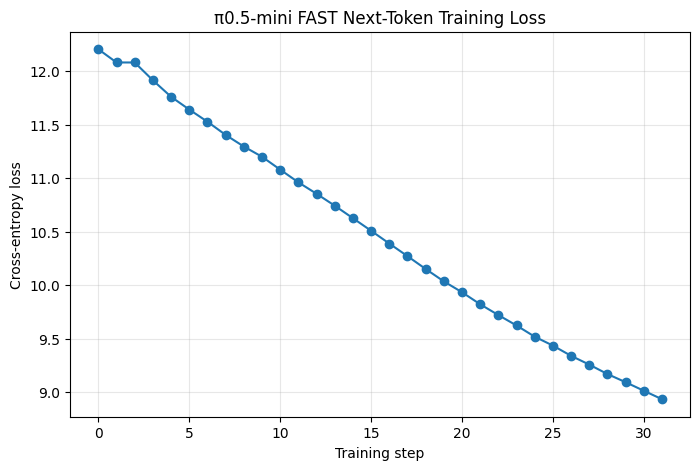


========== OVERFIT TEST COMPLETE ==========
total training steps: 31
initial loss: 12.205301284790039
final loss: 8.932478904724121
absolute reduction: 3.272822380065918
percent reduction: 26.814761091923497 %


In [24]:
# Cell 17 — Repeated training + live loss graph
#
# Goal:
# Repeatedly train π0.5-mini on the SAME robot example.
#
# This is an OVERFIT SANITY CHECK, not our final dataset training.
#
# If the implementation is correct, the model should progressively
# memorize this example and its FAST-token loss should fall.

import jax
import numpy as np
import optax

import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from flax.core import freeze, unfreeze


# ============================================================
# 1. Define one complete training step
#
# forward
#   ↓
# loss
#   ↓
# backward
#   ↓
# gradients
#   ↓
# AdamW
#   ↓
# updated parameters
# ============================================================

@jax.jit
def mini_train_step(
    params,
    opt_state,
):

    loss, grads = jax.value_and_grad(
        mini_loss_fn
    )(
        params
    )


    grad_norm = optax.global_norm(
        grads
    )


    updates, new_opt_state = optimizer.update(
        grads,
        opt_state,
        params,
    )


    new_params = optax.apply_updates(
        params,
        updates,
    )


    return (
        new_params,
        new_opt_state,
        loss,
        grad_norm,
    )


# ============================================================
# 2. Start history with Cells 15–16
#
# Step 0:
# initial random π0.5-mini
#
# Step 1:
# first optimizer update from Cell 16
# ============================================================

step_history = [
    0,
    1,
]

loss_history = [
    float(mini_loss_before),
    float(mini_loss_after),
]

grad_history = [
    float(global_grad_norm),
    np.nan,
]


print("========== STARTING TRAINING ==========")

print(
    "step 0 loss:",
    loss_history[0],
)

print(
    "step 1 loss:",
    loss_history[1],
)


# ============================================================
# 3. Train repeatedly
# ============================================================

ADDITIONAL_STEPS = 30


for step in range(
    2,
    2 + ADDITIONAL_STEPS,
):

    (
        mini_params,
        opt_state,
        loss,
        grad_norm,
    ) = mini_train_step(
        mini_params,
        opt_state,
    )


    # Make sure GPU computation has completed.
    loss = jax.block_until_ready(
        loss
    )

    grad_norm = jax.block_until_ready(
        grad_norm
    )


    loss_value = float(
        loss
    )

    grad_value = float(
        grad_norm
    )


    step_history.append(
        step
    )

    loss_history.append(
        loss_value
    )

    grad_history.append(
        grad_value
    )


    # --------------------------------------------------------
    # Update graph every two steps
    # --------------------------------------------------------

    if (
        step == 2
        or step % 2 == 0
        or step == ADDITIONAL_STEPS + 1
    ):

        clear_output(
            wait=True
        )


        print(
            "========== π0.5-MINI TRAINING =========="
        )

        print(
            "step:",
            step,
        )

        print(
            "loss:",
            loss_value,
        )

        print(
            "gradient norm:",
            grad_value,
        )

        print(
            "initial loss:",
            loss_history[0],
        )

        print(
            "loss reduction:",
            loss_history[0]
            - loss_value,
        )


        # -----------------------------------------------
        # Live loss graph
        # -----------------------------------------------

        fig = plt.figure(
            figsize=(8, 5)
        )

        plt.plot(
            step_history,
            loss_history,
            marker="o",
        )

        plt.xlabel(
            "Training step"
        )

        plt.ylabel(
            "Cross-entropy loss"
        )

        plt.title(
            "π0.5-mini FAST Next-Token Training Loss"
        )

        plt.grid(
            True,
            alpha=0.3,
        )

        display(
            fig
        )

        plt.close(
            fig
        )


# ============================================================
# 4. Put final trained parameters back into mini_variables
# ============================================================

mutable_variables = unfreeze(
    mini_variables
)

mutable_variables["params"] = (
    mini_params
)

mini_variables = freeze(
    mutable_variables
)


# ============================================================
# 5. Final training report
# ============================================================

print("\n========== OVERFIT TEST COMPLETE ==========")

print(
    "total training steps:",
    step_history[-1],
)

print(
    "initial loss:",
    loss_history[0],
)

print(
    "final loss:",
    loss_history[-1],
)

print(
    "absolute reduction:",
    loss_history[0]
    - loss_history[-1],
)

print(
    "percent reduction:",
    100
    * (
        loss_history[0]
        - loss_history[-1]
    )
    / loss_history[0],
    "%",
)

========== π0.5-MINI REAL DATA TRAINING ==========
step: 10000 / 10000
dataset index: 3030
loss: 2.4371607303619385
gradient norm: 10.338998794555664
10-step mean loss: 3.1145179986953737


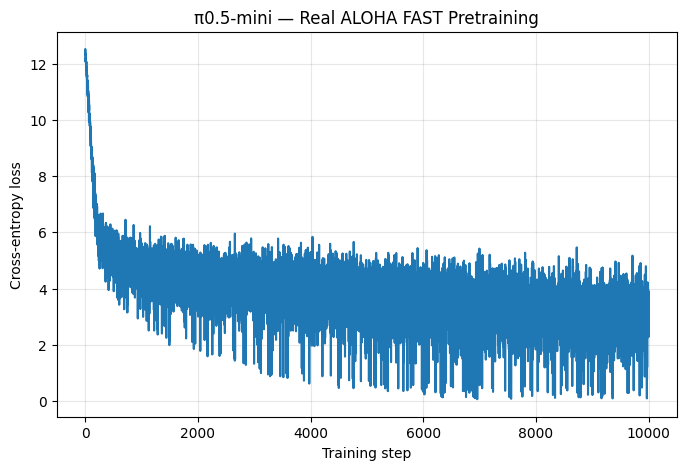


========== SMALL-SCALE PRETRAINING COMPLETE ==========
steps: 10000
unique frames sampled: 3060
first 10-step mean: 12.376890563964844
last 10-step mean: 3.1145179986953737
best observed loss: 0.05722082406282425


In [26]:
# Cell 18 — Actual small-scale π0.5-style pretraining
#
# Goal:
# Train π0.5-mini across many DIFFERENT real ALOHA examples.
#
# Unlike Cell 17:
#
# Cell 17:
#     same frame -> repeated memorization
#
# Cell 18:
#     different frames -> learn dataset distribution
#
# We reset the mini model first so the overfit experiment
# does not contaminate this training run.

import copy
import gc

import jax
import jax.numpy as jnp
import numpy as np
import optax

import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from flax import traverse_util
from flax.core import freeze, unfreeze

from openpi import transforms
from openpi.models import model as model_lib
from openpi.models import tokenizer as tokenizer_lib
from openpi.policies import aloha_policy


# ============================================================
# 1. Recreate the preprocessing pipeline explicitly
# ============================================================

aloha_train_transform = aloha_policy.AlohaInputs(
    adapt_to_pi=True
)

delta_mask = transforms.make_bool_mask(
    6, -1,
    6, -1,
)

delta_train_transform = transforms.DeltaActions(
    delta_mask
)

normalize_train_transform = transforms.Normalize(
    train_norm_stats,
    use_quantiles=True,
)

resize_train_transform = transforms.ResizeImages(
    224,
    224,
)

train_fast_tokenizer = tokenizer_lib.FASTTokenizer(
    max_len=250,
)

fast_train_transform = transforms.TokenizeFASTInputs(
    train_fast_tokenizer
)


# ============================================================
# 2. Convert one raw LeRobot frame into mini-model tensors
# ============================================================

def prepare_training_example(raw):

    sample = {
        "images": {
            "cam_high": np.asarray(
                raw["observation.images.cam_high"]
            ),
            "cam_low": np.asarray(
                raw["observation.images.cam_low"]
            ),
            "cam_left_wrist": np.asarray(
                raw["observation.images.cam_left_wrist"]
            ),
            "cam_right_wrist": np.asarray(
                raw["observation.images.cam_right_wrist"]
            ),
        },

        "state": np.asarray(
            raw["observation.state"]
        ),

        "actions": np.asarray(
            raw["action"]
        ),

        "prompt": raw["task"],
    }


    # ALOHA -> PI convention
    sample = aloha_train_transform(
        sample
    )

    # Absolute joints -> joint deltas
    sample = delta_train_transform(
        sample
    )

    # q01/q99 normalization from TRAIN episodes only
    sample = normalize_train_transform(
        sample
    )

    # Cameras -> 224 × 224
    sample = resize_train_transform(
        sample
    )

    # State + instruction + FAST actions -> token sequence
    sample = fast_train_transform(
        sample
    )


    # --------------------------------------------------------
    # Use Observation.from_dict() to get the same image
    # conversion we used earlier:
    #
    # uint8 [0,255]
    #      ↓
    # float32 [-1,+1]
    # --------------------------------------------------------

    obs_dict = {
        "image": {
            name: image[None]
            for name, image in sample["image"].items()
        },

        "image_mask": {
            name: np.asarray(
                [mask]
            )
            for name, mask in sample["image_mask"].items()
        },

        "state": sample["state"][None],

        "tokenized_prompt":
            sample["tokenized_prompt"][None],

        "tokenized_prompt_mask":
            sample["tokenized_prompt_mask"][None],

        "token_ar_mask":
            sample["token_ar_mask"][None],

        "token_loss_mask":
            sample["token_loss_mask"][None],
    }


    obs = model_lib.Observation.from_dict(
        obs_dict
    )


    return (
        jnp.asarray(
            obs.images["base_0_rgb"],
            dtype=jnp.float32,
        ),

        jnp.asarray(
            obs.images["left_wrist_0_rgb"],
            dtype=jnp.float32,
        ),

        jnp.asarray(
            obs.images["right_wrist_0_rgb"],
            dtype=jnp.float32,
        ),

        jnp.asarray(
            obs.tokenized_prompt,
            dtype=jnp.int32,
        ),

        jnp.asarray(
            obs.tokenized_prompt_mask,
            dtype=jnp.bool_,
        ),

        jnp.asarray(
            obs.token_ar_mask,
            dtype=jnp.int32,
        ),

        jnp.asarray(
            obs.token_loss_mask,
            dtype=jnp.bool_,
        ),
    )


# ============================================================
# 3. Reset π0.5-mini to fresh weights
#
# This ensures Cell 17's one-example memorization does NOT
# become the starting point for our real experiment.
# ============================================================

print("========== RESETTING MINI MODEL ==========")

fresh_rng = jax.random.key(
    42
)


example_batch = prepare_training_example(
    train_dataset[0]
)


fresh_variables = mini_model.init(
    fresh_rng,
    *example_batch[:6],
)


# ------------------------------------------------------------
# OpenPI's Gemma embedding table normally starts at zero
# because pretrained PaliGemma weights replace it.
#
# Our scratch mini-model again needs random embeddings.
# ------------------------------------------------------------

mutable = unfreeze(
    fresh_variables
)

flat = traverse_util.flatten_dict(
    mutable["params"]
)

embedding_paths = [
    path
    for path in flat
    if path[-1] == "input_embedding"
]

assert len(embedding_paths) == 1

embedding_path = embedding_paths[0]

embedding_shape = flat[
    embedding_path
].shape


flat[embedding_path] = (
    jax.random.normal(
        jax.random.key(1234),
        embedding_shape,
        dtype=jnp.float32,
    )
    * 0.02
)


mutable["params"] = (
    traverse_util.unflatten_dict(
        flat
    )
)

fresh_variables = freeze(
    mutable
)

train_params = fresh_variables[
    "params"
]


print("fresh parameters initialized")


# ============================================================
# 4. Fresh optimizer
# ============================================================

TRAIN_LR = 1e-4


train_optimizer = optax.chain(

    optax.clip_by_global_norm(
        1.0
    ),

    optax.adamw(
        learning_rate=TRAIN_LR,
        b1=0.9,
        b2=0.95,
        eps=1e-8,
        weight_decay=1e-10,
    ),
)


train_opt_state = train_optimizer.init(
    train_params
)


# ============================================================
# 5. Generic memory-safe loss
#
# Unlike Cell 15, this function does NOT assume that the
# supervised FAST tokens occur at the same positions for
# every example.
#
# Every sample has a fixed 249 possible next-token positions,
# and token_loss_mask decides which ones contribute.
# ============================================================

CE_CHUNK_SIZE = 16

TARGET_LENGTH = 249

PADDED_TARGET_LENGTH = (
    (
        TARGET_LENGTH
        + CE_CHUNK_SIZE
        - 1
    )
    // CE_CHUNK_SIZE
    * CE_CHUNK_SIZE
)

CE_PADDING = (
    PADDED_TARGET_LENGTH
    - TARGET_LENGTH
)

NUM_CE_CHUNKS = (
    PADDED_TARGET_LENGTH
    // CE_CHUNK_SIZE
)


def dataset_loss_fn(
    params,

    base_img,
    left_img,
    right_img,

    tokens,
    token_mask,
    ar_mask,
    loss_mask,
):

    # Full multimodal forward pass
    token_features, _, _ = mini_model.apply(
        {
            "params": params,
        },

        base_img,
        left_img,
        right_img,

        tokens,
        token_mask,
        ar_mask,
    )


    # Next-token targets
    targets = tokens[:, 1:]

    supervised_mask = (
        loss_mask[:, 1:]
        .astype(jnp.float32)
    )


    # Pad sequence for fixed-size CE chunks
    features = jnp.pad(
        token_features,
        (
            (0, 0),
            (0, CE_PADDING),
            (0, 0),
        ),
    )


    targets = jnp.pad(
        targets,
        (
            (0, 0),
            (0, CE_PADDING),
        ),
    )


    supervised_mask = jnp.pad(
        supervised_mask,
        (
            (0, 0),
            (0, CE_PADDING),
        ),
    )


    features = (
        features
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
            MINI_WIDTH,
        )
        .transpose(
            1, 0, 2, 3
        )
    )


    targets = (
        targets
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
        )
        .transpose(
            1, 0, 2
        )
    )


    supervised_mask = (
        supervised_mask
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
        )
        .transpose(
            1, 0, 2
        )
    )


    embedding_table = (
        params["llm"]
        ["embedder"]
        ["input_embedding"]
    )


    @jax.checkpoint
    def ce_chunk(
        running,
        xs,
    ):

        features_i, targets_i, mask_i = xs


        logits = jnp.matmul(
            features_i.astype(
                jnp.float32
            ),

            embedding_table
            .astype(jnp.float32)
            .T,
        )


        log_partition = (
            jax.scipy.special.logsumexp(
                logits,
                axis=-1,
            )
        )


        correct_logits = (
            jnp.take_along_axis(
                logits,
                targets_i[..., None],
                axis=-1,
            )
            .squeeze(-1)
        )


        token_ce = (
            log_partition
            - correct_logits
        )


        running = (
            running
            + jnp.sum(
                token_ce * mask_i
            )
        )


        return running, None


    total_loss, _ = jax.lax.scan(
        ce_chunk,

        jnp.asarray(
            0.0,
            dtype=jnp.float32,
        ),

        (
            features,
            targets,
            supervised_mask,
        ),
    )


    num_supervised = jnp.maximum(
        supervised_mask.sum(),
        1.0,
    )


    return (
        total_loss
        / num_supervised
    )


# ============================================================
# 6. One generic training step
# ============================================================

@jax.jit
def dataset_train_step(
    params,
    opt_state,
    batch,
):

    (
        loss,
        grads,
    ) = jax.value_and_grad(
        dataset_loss_fn
    )(
        params,
        *batch,
    )


    grad_norm = optax.global_norm(
        grads
    )


    updates, new_opt_state = (
        train_optimizer.update(
            grads,
            opt_state,
            params,
        )
    )


    new_params = optax.apply_updates(
        params,
        updates,
    )


    return (
        new_params,
        new_opt_state,
        loss,
        grad_norm,
    )


# ============================================================
# 7. Actual small-scale pretraining
# ============================================================

TRAIN_STEPS = 10000

rng_np = np.random.default_rng(
    0
)

train_losses = []
train_grad_norms = []
sampled_indices = []


print("\n========== SMALL-SCALE PRETRAINING ==========")

print(
    "training frames available:",
    len(train_dataset),
)

print(
    "training steps:",
    TRAIN_STEPS,
)

print(
    "learning rate:",
    TRAIN_LR,
)


for step in range(
    TRAIN_STEPS
):

    # Random real robot frame from episodes 0–7
    index = int(
        rng_np.integers(
            0,
            len(train_dataset),
        )
    )

    sampled_indices.append(
        index
    )


    raw = train_dataset[
        index
    ]


    batch = prepare_training_example(
        raw
    )


    (
        train_params,
        train_opt_state,
        loss,
        grad_norm,
    ) = dataset_train_step(
        train_params,
        train_opt_state,
        batch,
    )


    loss = jax.block_until_ready(
        loss
    )

    grad_norm = jax.block_until_ready(
        grad_norm
    )


    loss_value = float(
        loss
    )

    grad_value = float(
        grad_norm
    )


    train_losses.append(
        loss_value
    )

    train_grad_norms.append(
        grad_value
    )


    # --------------------------------------------------------
    # Live graph every 5 steps
    # --------------------------------------------------------

    if (
        step == 0
        or (step + 1) % 5 == 0
    ):

        clear_output(
            wait=True
        )


        recent = train_losses[
            -10:
        ]


        print(
            "========== π0.5-MINI REAL DATA TRAINING =========="
        )

        print(
            "step:",
            step + 1,
            "/",
            TRAIN_STEPS,
        )

        print(
            "dataset index:",
            index,
        )

        print(
            "loss:",
            loss_value,
        )

        print(
            "gradient norm:",
            grad_value,
        )

        print(
            "10-step mean loss:",
            float(
                np.mean(recent)
            ),
        )


        fig = plt.figure(
            figsize=(8, 5)
        )

        plt.plot(
            np.arange(
                1,
                len(train_losses) + 1,
            ),
            train_losses,
        )

        plt.xlabel(
            "Training step"
        )

        plt.ylabel(
            "Cross-entropy loss"
        )

        plt.title(
            "π0.5-mini — Real ALOHA FAST Pretraining"
        )

        plt.grid(
            True,
            alpha=0.3,
        )

        display(
            fig
        )

        plt.close(
            fig
        )


# ============================================================
# 8. Save current trained model state in notebook
# ============================================================

trained_mini_variables = freeze(
    {
        "params": train_params,
    }
)


# ============================================================
# 9. Training summary
# ============================================================

print(
    "\n========== SMALL-SCALE PRETRAINING COMPLETE =========="
)

print(
    "steps:",
    TRAIN_STEPS,
)

print(
    "unique frames sampled:",
    len(
        set(
            sampled_indices
        )
    ),
)

print(
    "first 10-step mean:",
    float(
        np.mean(
            train_losses[:10]
        )
    ),
)

print(
    "last 10-step mean:",
    float(
        np.mean(
            train_losses[-10:]
        )
    ),
)

print(
    "best observed loss:",
    float(
        np.min(
            train_losses
        )
    ),
)

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

========== VALIDATION DATASET ==========
held-out episodes: [8, 9]
validation frames: 800
first global frame index: 3200
last global frame index: 3999

========== RUNNING HELD-OUT EVALUATION ==========
   1 / 800 | fresh mean: 12.4625 | trained mean: 4.9996
 100 / 800 | fresh mean: 12.5146 | trained mean: 4.5247
 200 / 800 | fresh mean: 12.5133 | trained mean: 4.5764
 300 / 800 | fresh mean: 12.5157 | trained mean: 4.6145
 400 / 800 | fresh mean: 12.5098 | trained mean: 4.5308
 500 / 800 | fresh mean: 12.5109 | trained mean: 4.4365
 600 / 800 | fresh mean: 12.5103 | trained mean: 4.5154
 700 / 800 | fresh mean: 12.5093 | trained mean: 4.5117
 800 / 800 | fresh mean: 12.5101 | trained mean: 4.5190

========== HELD-OUT VALIDATION RESULTS ==========
fresh model mean loss: 12.510109833478928
trained model mean loss: 4.518967345952988
absolute improvement: 7.9911424875259405
percent improvement: 63.87747664805025 %

fresh median loss:
12.512792110443115
trained median loss:
4.55095672607421

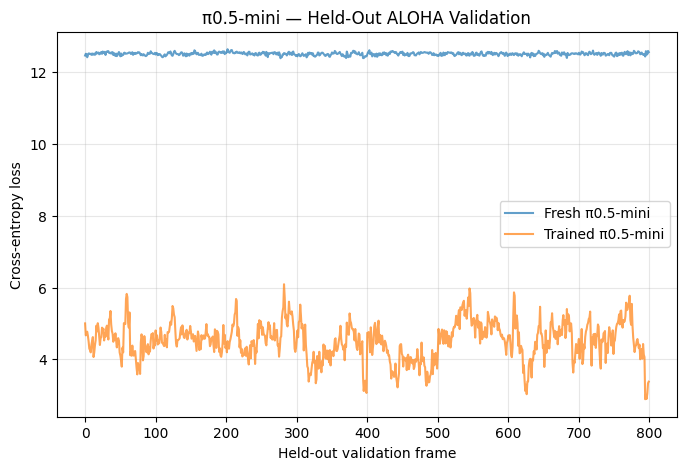

In [29]:
# Cell 19 — Held-out validation
#
# Goal:
# Evaluate π0.5-mini on episodes 8 and 9, which were NEVER
# used for optimizer updates or normalization-stat computation.
#
# We compare:
#
#   fresh random π0.5-mini
#            vs
#   10,000-step trained π0.5-mini
#
# on exactly the same held-out robot frames.

import jax
import numpy as np
import matplotlib.pyplot as plt

from lerobot.common.datasets.lerobot_dataset import LeRobotDataset


# ============================================================
# 1. Construct held-out validation source
#
# Work around this LeRobot version's episode-subset indexing
# issue by opening the full dataset, then selecting the frame
# indices belonging specifically to episodes 8 and 9.
# ============================================================

val_source = LeRobotDataset(
    repo_id=REPO_ID,

    delta_timestamps={
        "action": action_delta_timestamps,
    },
)


val_indices = []

for episode_id in VAL_EPISODES:

    start = int(
        val_source.episode_data_index["from"][episode_id]
    )

    end = int(
        val_source.episode_data_index["to"][episode_id]
    )

    val_indices.extend(
        range(start, end)
    )


print("========== VALIDATION DATASET ==========")

print("held-out episodes:", VAL_EPISODES)
print("validation frames:", len(val_indices))

print(
    "first global frame index:",
    val_indices[0],
)

print(
    "last global frame index:",
    val_indices[-1],
)


# ============================================================
# 2. Get the two models we want to compare
# ============================================================

# Completely fresh π0.5-mini from the beginning of Cell 18.
fresh_params = fresh_variables[
    "params"
]


# Current parameters after 10,000 optimizer updates.
trained_params = train_params


# ============================================================
# 3. JIT the validation loss
#
# Same exact objective as training.
# No gradients.
# No optimizer.
# No parameter updates.
# ============================================================

@jax.jit
def eval_loss(
    params,
    batch,
):

    return dataset_loss_fn(
        params,
        *batch,
    )


# ============================================================
# 4. Evaluate every held-out frame
#
# 2 episodes × ~400 frames = ~800 examples.
# ============================================================

fresh_val_losses = []
trained_val_losses = []


print("\n========== RUNNING HELD-OUT EVALUATION ==========")


for i, dataset_index in enumerate(val_indices):

    batch = prepare_training_example(
        val_source[dataset_index]
    )


    fresh_loss = eval_loss(
        fresh_params,
        batch,
    )


    trained_loss = eval_loss(
        trained_params,
        batch,
    )


    fresh_loss = float(
        jax.device_get(
            jax.block_until_ready(
                fresh_loss
            )
        )
    )


    trained_loss = float(
        jax.device_get(
            jax.block_until_ready(
                trained_loss
            )
        )
    )


    fresh_val_losses.append(
        fresh_loss
    )

    trained_val_losses.append(
        trained_loss
    )


    if (
        i == 0
        or (i + 1) % 100 == 0
    ):

        print(
            f"{i + 1:4d} / {len(val_indices)}",
            "| fresh mean:",
            f"{np.mean(fresh_val_losses):.4f}",
            "| trained mean:",
            f"{np.mean(trained_val_losses):.4f}",
        )


# ============================================================
# 5. Final statistics
# ============================================================

fresh_val_losses = np.asarray(
    fresh_val_losses
)

trained_val_losses = np.asarray(
    trained_val_losses
)


fresh_mean = float(
    fresh_val_losses.mean()
)

trained_mean = float(
    trained_val_losses.mean()
)


print("\n========== HELD-OUT VALIDATION RESULTS ==========")

print(
    "fresh model mean loss:",
    fresh_mean,
)

print(
    "trained model mean loss:",
    trained_mean,
)

print(
    "absolute improvement:",
    fresh_mean - trained_mean,
)

print(
    "percent improvement:",
    100
    * (
        fresh_mean - trained_mean
    )
    / fresh_mean,
    "%",
)


print("\nfresh median loss:")
print(
    float(
        np.median(
            fresh_val_losses
        )
    )
)

print("trained median loss:")
print(
    float(
        np.median(
            trained_val_losses
        )
    )
)


# ============================================================
# 6. Visual comparison
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    fresh_val_losses,
    label="Fresh π0.5-mini",
    alpha=0.7,
)


plt.plot(
    trained_val_losses,
    label="Trained π0.5-mini",
    alpha=0.7,
)


plt.xlabel(
    "Held-out validation frame"
)

plt.ylabel(
    "Cross-entropy loss"
)

plt.title(
    "π0.5-mini — Held-Out ALOHA Validation"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3,
)

plt.show()

========== π0.5-MINI REAL DATA TRAINING ==========
step: 10000 / 10000
dataset index: 3030
loss: 1.6802520751953125
gradient norm: 11.672810554504395
10-step mean loss: 1.5542636513710022


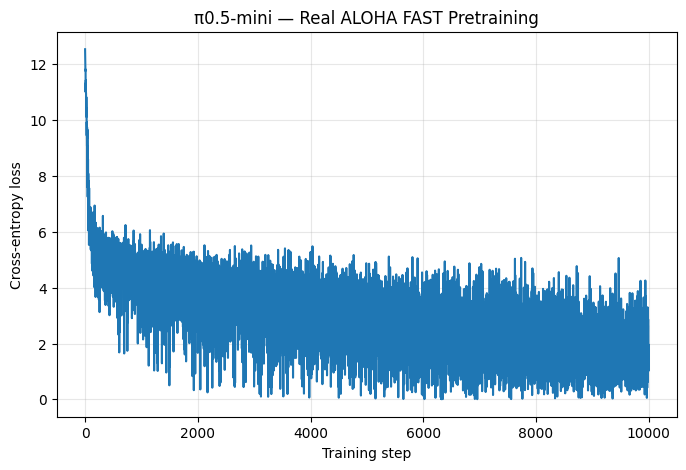


========== SMALL-SCALE PRETRAINING COMPLETE ==========
steps: 10000
unique frames sampled: 3060
first 10-step mean: 12.021377182006836
last 10-step mean: 1.5542636513710022
best observed loss: 0.004587991163134575


Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

========== VALIDATION DATASET ==========
held-out episodes: [8, 9]
validation frames: 800
first global frame index: 3200
last global frame index: 3999

========== RUNNING HELD-OUT EVALUATION ==========
   1 / 800 | fresh mean: 12.5243 | trained mean: 5.0816
 100 / 800 | fresh mean: 12.5274 | trained mean: 4.7997
 200 / 800 | fresh mean: 12.5401 | trained mean: 4.8137
 300 / 800 | fresh mean: 12.5502 | trained mean: 4.8178
 400 / 800 | fresh mean: 12.5445 | trained mean: 4.6848
 500 / 800 | fresh mean: 12.5441 | trained mean: 4.6148
 600 / 800 | fresh mean: 12.5467 | trained mean: 4.6850
 700 / 800 | fresh mean: 12.5474 | trained mean: 4.6767
 800 / 800 | fresh mean: 12.5465 | trained mean: 4.6815

========== HELD-OUT VALIDATION RESULTS ==========
fresh model mean loss: 12.546450115442276
trained model mean loss: 4.681489370763302
absolute improvement: 7.864960744678974
percent improvement: 62.6867414472777 %

fresh median loss:
12.546579837799072
trained median loss:
4.709291458129883


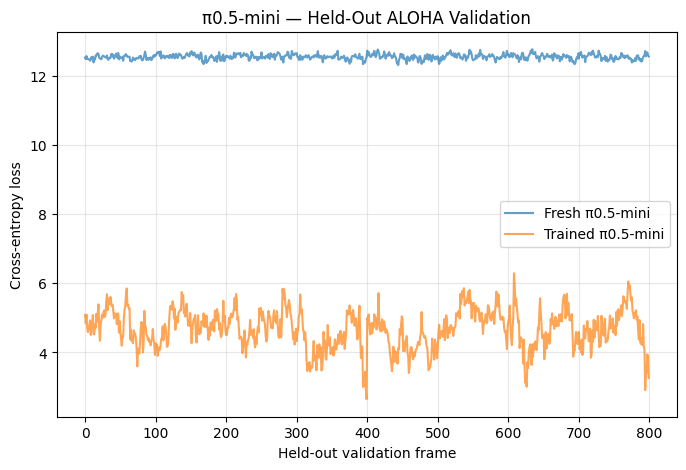

In [33]:
# ============================================================
# CLEAR PREVIOUS MINI-MODEL GPU STATE
# ============================================================

import gc
import jax

for name in [
    # model / parameter states
    "mini_model",
    "mini_variables",
    "mini_params",
    "trained_mini_variables",
    "fresh_variables",
    "fresh_params",
    "train_params",

    # gradients / updates
    "mini_grads",
    "updates",

    # optimizer states
    "opt_state",
    "train_opt_state",
    "optimizer",
    "train_optimizer",

    # large intermediate tensors
    "mini_features",
    "token_losses",

    # compiled functions that close over model state
    "loss_and_grad_fn",
    "mini_train_step",
    "dataset_train_step",
    "eval_loss",
]:
    globals().pop(name, None)

gc.collect()

# Clears JAX's compiled executable caches.
# Buffers are only freed if no Python references remain,
# which is why the deletes above matter.
jax.clear_caches()

print("Previous mini-model training state released.")
print("devices:", jax.devices())



# Cell 14 — Build a fully trainable π0.5-mini
#
# Goal:
# Preserve the π0.5 FAST pretraining computation while shrinking
# the neural network enough that we can perform FULL backpropagation.
#
# This is NOT LoRA.
# No layers are frozen.
# Every parameter in this miniature model will be trainable.

import gc

import flax.linen as nn
from flax.core import freeze, unfreeze
import flax.traverse_util as traverse_util

import jax
import jax.numpy as jnp
import numpy as np

from openpi.models import gemma_fast
from openpi.models import pi0_fast
from openpi.models import siglip


# ============================================================
# 1. RELEASE THE 2.9B MODEL
# ============================================================
#
# Keep:
#   observation
#   actions_batch
#
# Those contain our small prepared training example.
#
# Release large model / activation objects from Cells 9-13.

for name in [
    "model",
    "graphdef",
    "state",
    "random_params",
    "flat_random",
    "loaded_params",
    "flat_loaded",
    "embedded_inputs",
    "pre_logits",
    "token_pre_logits",
    "inspect_logits",
    "supervised_features",
]:
    globals().pop(name, None)

gc.collect()

# Clears JAX compilation caches. Device buffers whose Python
# references disappeared above can now be reused.
jax.clear_caches()

print("========== LARGE MODEL RELEASED ==========")
print("devices:", jax.devices())


# ============================================================
# 2. DEFINE THE MINIATURE ARCHITECTURE
# ============================================================

MINI_WIDTH = 768
MINI_DEPTH = 16
MINI_MLP_DIM = 3072

MINI_NUM_HEADS = 12
MINI_NUM_KV_HEADS = 1
MINI_HEAD_DIM = 64

VOCAB_SIZE = 257_152


class Pi05Mini(nn.Module):
    """Small fully-trainable reproduction of π0.5 FAST pretraining."""

    width: int = MINI_WIDTH
    depth: int = MINI_DEPTH
    mlp_dim: int = MINI_MLP_DIM

    def setup(self):

        # ----------------------------------------------------
        # Tiny vision transformer
        #
        # OpenPI's SigLIP implementation already contains a
        # "mu" configuration:
        #
        # width = 32
        # depth = 1
        # heads = 2
        #
        # We use 28x28 patches to reduce image-token count:
        #
        # 224x224 -> 8x8 -> 64 tokens / camera
        # ----------------------------------------------------

        self.img = siglip.Module(
            num_classes=self.width,
            variant="mu/28",
            pool_type="none",

            # Important because we're training from scratch.
            # The normal PI model expects pretrained vision weights.
            head_zeroinit=False,

            scan=False,
            dtype_mm="bfloat16",
        )

        # ----------------------------------------------------
        # Tiny Gemma-style autoregressive transformer
        #
        # Same OpenPI Gemma implementation as Pi0FAST,
        # drastically reduced dimensions.
        # ----------------------------------------------------

        self.llm = gemma_fast.Module(
            variant="pi05_mini",

            width=self.width,
            depth=self.depth,
            mlp_dim=self.mlp_dim,

            num_heads=MINI_NUM_HEADS,
            num_kv_heads=MINI_NUM_KV_HEADS,
            head_dim=MINI_HEAD_DIM,

            norm_eps=1e-6,

            # Keep the REAL PaliGemma vocabulary so our existing
            # FAST token IDs remain valid.
            vocab_size=VOCAB_SIZE,

            embed_dtype="bfloat16",
            cache_dtype="bfloat16",

            scan=True,

            # Recompute activations during backward pass instead
            # of storing everything. Saves training VRAM.
            remat_policy="nothing_saveable",
        )


    def __call__(
        self,
        base_image,
        left_wrist_image,
        right_wrist_image,
        tokens,
        token_mask,
        token_ar_mask,
    ):

        # ----------------------------------------------------
        # Encode all three robot cameras
        # ----------------------------------------------------

        base_embeddings, _ = self.img(
            base_image,
            train=True,
        )

        left_embeddings, _ = self.img(
            left_wrist_image,
            train=True,
        )

        right_embeddings, _ = self.img(
            right_wrist_image,
            train=True,
        )


        # ----------------------------------------------------
        # Embed language/state/FAST token IDs
        # ----------------------------------------------------

        token_embeddings = self.llm(
            tokens,
            embed_only=True,
        )


        # ----------------------------------------------------
        # Concatenate vision + token modalities
        #
        # Expected:
        #
        # 64 + 64 + 64 image tokens
        # +
        # 250 token slots
        #
        # = 442 total positions
        # ----------------------------------------------------

        embedded_inputs = jnp.concatenate(
            [
                base_embeddings,
                left_embeddings,
                right_embeddings,
                token_embeddings,
            ],
            axis=1,
        )


        batch_size = tokens.shape[0]

        image_token_count = (
            base_embeddings.shape[1]
            + left_embeddings.shape[1]
            + right_embeddings.shape[1]
        )


        # All three cameras exist in this dataset.
        image_mask = jnp.ones(
            (batch_size, image_token_count),
            dtype=jnp.bool_,
        )

        image_ar_mask = jnp.zeros(
            (batch_size, image_token_count),
            dtype=jnp.int32,
        )


        combined_input_mask = jnp.concatenate(
            [
                image_mask,
                token_mask,
            ],
            axis=1,
        )

        combined_ar_mask = jnp.concatenate(
            [
                image_ar_mask,
                token_ar_mask,
            ],
            axis=1,
        )


        # ----------------------------------------------------
        # Same block-causal attention logic as Pi0FAST
        # ----------------------------------------------------

        attention_mask = pi0_fast.make_attn_mask(
            combined_input_mask,
            combined_ar_mask,
        )


        # ----------------------------------------------------
        # Autoregressive transformer
        #
        # Drop final input because position i predicts i+1.
        # ----------------------------------------------------

        pre_logits, _, _ = self.llm(
            embedded_prefix=embedded_inputs[:, :-1],
            mask=attention_mask[:, :-1, :-1],
            return_prelogits=True,
        )


        # Keep only the transformer outputs corresponding to
        # the 249 shifted text/state/action targets.
        token_prediction_features = pre_logits[
            :,
            -(tokens.shape[1] - 1):,
            :,
        ]


        return (
            token_prediction_features,
            base_embeddings.shape[1],
            embedded_inputs.shape[1],
        )


# ============================================================
# 3. PREPARE THE SAME REAL ROBOT INPUT FROM CELL 10/11
# ============================================================

base_image = jnp.asarray(
    observation.images["base_0_rgb"],
    dtype=jnp.float32,
)

left_image = jnp.asarray(
    observation.images["left_wrist_0_rgb"],
    dtype=jnp.float32,
)

right_image = jnp.asarray(
    observation.images["right_wrist_0_rgb"],
    dtype=jnp.float32,
)

mini_tokens = jnp.asarray(
    observation.tokenized_prompt,
    dtype=jnp.int32,
)

mini_token_mask = jnp.asarray(
    observation.tokenized_prompt_mask,
    dtype=jnp.bool_,
)

mini_ar_mask = jnp.asarray(
    observation.token_ar_mask,
    dtype=jnp.int32,
)


print("\n========== MINI MODEL INPUT ==========")

print("base image:", base_image.shape)
print("left wrist:", left_image.shape)
print("right wrist:", right_image.shape)
print("tokens:", mini_tokens.shape)


# ============================================================
# 4. INITIALIZE THE MINIATURE MODEL
# ============================================================

mini_model = Pi05Mini()

mini_rng = jax.random.key(42)


mini_variables = mini_model.init(
    mini_rng,

    base_image,
    left_image,
    right_image,

    mini_tokens,
    mini_token_mask,
    mini_ar_mask,
)


# ============================================================
# 5. IMPORTANT: RANDOMIZE TOKEN EMBEDDINGS
# ============================================================
#
# OpenPI's Gemma embedder starts at zero because normally PI
# immediately replaces it with pretrained PaliGemma weights.
#
# Our miniature model cannot load those weights because:
#
# PaliGemma embedding width = 2048
# mini embedding width      = 256
#
# So for this scratch-training demonstration we explicitly
# initialize the embedding matrix randomly.

mutable_variables = unfreeze(
    mini_variables
)


flat_params = traverse_util.flatten_dict(
    mutable_variables["params"],
)


embedding_paths = [
    path
    for path in flat_params
    if path[-1] == "input_embedding"
]


print("\nembedding paths found:")

for path in embedding_paths:
    print("/".join(path))


assert len(embedding_paths) == 1


embedding_path = embedding_paths[0]

embedding = flat_params[
    embedding_path
]


embed_rng = jax.random.key(1234)

flat_params[embedding_path] = (
    jax.random.normal(
        embed_rng,
        embedding.shape,
        dtype=jnp.float32,
    )
    * 0.02
)


mutable_variables["params"] = (
    traverse_util.unflatten_dict(
        flat_params
    )
)

mini_variables = freeze(
    mutable_variables
)


# ============================================================
# 6. COUNT PARAMETERS
# ============================================================

flat_params = traverse_util.flatten_dict(
    mini_variables["params"],
    sep="/",
)


num_params = sum(
    int(np.prod(value.shape))
    for value in flat_params.values()
)


print("\n========== π0.5-MINI ARCHITECTURE ==========")

print("transformer width:", MINI_WIDTH)
print("transformer depth:", MINI_DEPTH)
print("MLP dimension:", MINI_MLP_DIM)

print("attention heads:", MINI_NUM_HEADS)
print("head dimension:", MINI_HEAD_DIM)

print("\ntotal parameters:")
print(f"{num_params:,}")

print(
    "millions of parameters:",
    num_params / 1e6,
)


# ============================================================
# 7. VERIFY A MINI FORWARD PASS
# ============================================================

(
    mini_features,
    image_tokens_per_camera,
    mini_sequence_length,
) = mini_model.apply(
    mini_variables,

    base_image,
    left_image,
    right_image,

    mini_tokens,
    mini_token_mask,
    mini_ar_mask,
)


mini_features = jax.block_until_ready(
    mini_features
)


print("\n========== MINI FORWARD PASS ==========")

print(
    "image tokens per camera:",
    image_tokens_per_camera,
)

print(
    "total image tokens:",
    image_tokens_per_camera * 3,
)

print(
    "combined sequence length:",
    mini_sequence_length,
)

print(
    "token prediction features:",
    mini_features.shape,
)

print(
    "feature dtype:",
    mini_features.dtype,
)


print("\n========== TRAINING STATUS ==========")

print("frozen parameters: 0")
print("trainable parameters:", f"{num_params:,}")
print("LoRA: False")
print("full backpropagation: YES")

# Cell 15 — Full backpropagation through π0.5-mini
#
# Goal:
# Compute the FAST next-token cross-entropy and differentiate
# it through EVERY parameter of the miniature model.
#
# This is real backpropagation.
#
# However:
#   gradients are computed
#   weights are NOT changed yet
#
# Cell 16 will apply the optimizer update.

import jax
import jax.numpy as jnp
import numpy as np
import optax

from flax import traverse_util


# ============================================================
# 1. Reconstruct the supervised next-token targets
# ============================================================

mini_target_ids = mini_tokens[:, 1:]

mini_loss_mask = jnp.asarray(
    observation.token_loss_mask[:, 1:],
    dtype=jnp.bool_,
)


# Use NumPy here because these positions are fixed for this
# training example and should remain static during compilation.
supervised_positions_np = np.flatnonzero(
    np.asarray(
        jax.device_get(
            mini_loss_mask[0]
        )
    )
).astype(np.int32)


NUM_SUPERVISED = len(
    supervised_positions_np
)


print("========== TRAINING TARGETS ==========")

print(
    "supervised next-token targets:",
    NUM_SUPERVISED,
)

print(
    "first position:",
    supervised_positions_np[0],
)

print(
    "last position:",
    supervised_positions_np[-1],
)


# ============================================================
# 2. Prepare fixed target token IDs
# ============================================================

supervised_positions_jax = jnp.asarray(
    supervised_positions_np,
    dtype=jnp.int32,
)


supervised_target_ids = mini_target_ids[
    :,
    supervised_positions_jax,
]


print(
    "target IDs shape:",
    supervised_target_ids.shape,
)


# ============================================================
# 3. Cross-entropy chunking configuration
#
# Instead of creating:
#
#   58 × 257152 logits
#
# simultaneously during backprop, only decode four token
# positions at once.
# ============================================================

CE_CHUNK_SIZE = 4

PADDED_SUPERVISED = (
    (
        NUM_SUPERVISED
        + CE_CHUNK_SIZE
        - 1
    )
    // CE_CHUNK_SIZE
    * CE_CHUNK_SIZE
)

NUM_CE_CHUNKS = (
    PADDED_SUPERVISED
    // CE_CHUNK_SIZE
)

PAD_AMOUNT = (
    PADDED_SUPERVISED
    - NUM_SUPERVISED
)


print("\n========== MEMORY-SAFE CE ==========")

print(
    "CE chunk size:",
    CE_CHUNK_SIZE,
)

print(
    "number of CE chunks:",
    NUM_CE_CHUNKS,
)

print(
    "padding positions:",
    PAD_AMOUNT,
)


# ============================================================
# 4. Define the complete π0.5-mini loss
# ============================================================

def mini_loss_fn(params):

    # --------------------------------------------------------
    # FULL forward pass:
    #
    # cameras
    #   ↓
    # tiny vision transformer
    #
    # token IDs
    #   ↓
    # embedding table
    #
    # concatenate
    #   ↓
    # 4-layer Gemma transformer
    # --------------------------------------------------------

    (
        token_features,
        _,
        _,
    ) = mini_model.apply(
        {
            "params": params,
        },

        base_image,
        left_image,
        right_image,

        mini_tokens,
        mini_token_mask,
        mini_ar_mask,
    )


    # --------------------------------------------------------
    # Keep only supervised positions
    #
    # (1, 249, 256)
    #
    #       ↓
    #
    # (1, 58, 256)
    # --------------------------------------------------------

    supervised_features = token_features[
        :,
        supervised_positions_jax,
        :,
    ]


    # --------------------------------------------------------
    # Pad to a multiple of CE_CHUNK_SIZE.
    # Padding contributes zero loss.
    # --------------------------------------------------------

    supervised_features = jnp.pad(
        supervised_features,
        (
            (0, 0),
            (0, PAD_AMOUNT),
            (0, 0),
        ),
    )


    padded_targets = jnp.pad(
        supervised_target_ids,
        (
            (0, 0),
            (0, PAD_AMOUNT),
        ),
    )


    valid_loss_positions = jnp.concatenate(
        [
            jnp.ones(
                (1, NUM_SUPERVISED),
                dtype=jnp.float32,
            ),

            jnp.zeros(
                (1, PAD_AMOUNT),
                dtype=jnp.float32,
            ),
        ],
        axis=1,
    )


    # --------------------------------------------------------
    # Reshape into tiny CE groups
    #
    # features:
    # (1, 60, 256)
    #
    # →
    #
    # (15, 1, 4, 256)
    # --------------------------------------------------------

    feature_chunks = (
        supervised_features
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
            MINI_WIDTH,
        )
        .transpose(
            1, 0, 2, 3
        )
    )


    target_chunks = (
        padded_targets
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
        )
        .transpose(
            1, 0, 2
        )
    )


    mask_chunks = (
        valid_loss_positions
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
        )
        .transpose(
            1, 0, 2
        )
    )


    # --------------------------------------------------------
    # Gemma uses the SAME embedding matrix for:
    #
    # token embedding:
    # token ID → vector
    #
    # vocabulary decoding:
    # vector → vocabulary logits
    #
    # This is weight tying.
    # --------------------------------------------------------

    embedding_table = (
        params["llm"]
        ["embedder"]
        ["input_embedding"]
    )


    # --------------------------------------------------------
    # One tiny CE calculation.
    #
    # checkpoint/remat means large temporary logits do not
    # need to remain stored throughout backward propagation.
    # --------------------------------------------------------

    @jax.checkpoint
    def ce_chunk(
        running_loss,
        xs,
    ):

        features, targets, mask = xs


        # -----------------------------------------------
        # Same operation as Gemma Embedder.decode():
        #
        # features
        #   @
        # embedding_table.T
        #
        # →
        #
        # vocabulary logits
        # -----------------------------------------------

        logits = jnp.matmul(
            features.astype(jnp.float32),

            embedding_table
            .astype(jnp.float32)
            .T,
        )


        # -----------------------------------------------
        # Cross entropy without one-hot vectors:
        #
        # CE =
        #
        # log Σ exp(logit_j)
        # -
        # logit_correct
        # -----------------------------------------------

        log_partition = (
            jax.scipy.special.logsumexp(
                logits,
                axis=-1,
            )
        )


        correct_logits = (
            jnp.take_along_axis(
                logits,
                targets[..., None],
                axis=-1,
            )
            .squeeze(-1)
        )


        token_ce = (
            log_partition
            - correct_logits
        )


        chunk_loss = jnp.sum(
            token_ce * mask
        )


        return (
            running_loss + chunk_loss,
            None,
        )


    # --------------------------------------------------------
    # Sequentially evaluate the 15 tiny vocabulary projections
    # --------------------------------------------------------

    total_loss, _ = jax.lax.scan(
        ce_chunk,

        jnp.asarray(
            0.0,
            dtype=jnp.float32,
        ),

        (
            feature_chunks,
            target_chunks,
            mask_chunks,
        ),
    )


    # Same reduction as Pi0FAST:
    # mean CE over supervised tokens.
    return (
        total_loss
        / NUM_SUPERVISED
    )


# ============================================================
# 5. Extract all 69.7M trainable parameters
# ============================================================

mini_params = mini_variables[
    "params"
]


# ============================================================
# 6. Compile loss + FULL gradient calculation
# ============================================================

print(
    "\n========== COMPILING / BACKPROPAGATING =========="
)

print(
    "This first run may take a while because JAX must compile it."
)


loss_and_grad_fn = jax.jit(
    jax.value_and_grad(
        mini_loss_fn
    )
)


mini_loss_before, mini_grads = (
    loss_and_grad_fn(
        mini_params
    )
)


# Force GPU computation to finish.
mini_loss_before = jax.block_until_ready(
    mini_loss_before
)


print(
    "\nbackpropagation complete."
)


# ============================================================
# 7. Inspect the loss
# ============================================================

print(
    "\n========== π0.5-MINI LOSS =========="
)

print(
    "cross-entropy:",
    float(mini_loss_before),
)


# ============================================================
# 8. Inspect global gradient magnitude
# ============================================================

global_grad_norm = optax.global_norm(
    mini_grads
)

global_grad_norm = jax.block_until_ready(
    global_grad_norm
)


print(
    "\n========== GRADIENTS =========="
)

print(
    "global gradient norm:",
    float(global_grad_norm),
)


# ============================================================
# 9. Prove gradients reached the different parts of the model
# ============================================================

flat_grads = traverse_util.flatten_dict(
    mini_grads,
    sep="/",
)


def subtree_grad_norm(prefix):

    selected = [
        grad
        for path, grad in flat_grads.items()
        if path.startswith(prefix)
    ]

    if not selected:
        return 0.0

    sq_sum = sum(
        jnp.sum(
            grad.astype(jnp.float32) ** 2
        )
        for grad in selected
    )

    return float(
        jax.device_get(
            jnp.sqrt(sq_sum)
        )
    )


vision_grad_norm = subtree_grad_norm(
    "img/"
)

transformer_grad_norm = subtree_grad_norm(
    "llm/layers/"
)

embedding_grad_norm = subtree_grad_norm(
    "llm/embedder/"
)


print(
    "vision encoder grad norm:",
    vision_grad_norm,
)

print(
    "transformer grad norm:",
    transformer_grad_norm,
)

print(
    "token embedding grad norm:",
    embedding_grad_norm,
)


# ============================================================
# 10. Inspect a few actual gradient tensors
# ============================================================

print(
    "\n========== SAMPLE GRADIENT TENSORS =========="
)


shown = 0

for path, grad in flat_grads.items():

    grad_norm = float(
        jax.device_get(
            jnp.linalg.norm(
                grad.astype(jnp.float32)
            )
        )
    )

    if grad_norm > 0:

        print(
            path,
            "shape=",
            grad.shape,
            "norm=",
            grad_norm,
        )

        shown += 1

    if shown >= 8:
        break


print(
    "\n========== CELL 15 SUMMARY =========="
)

print(
    "loss:",
    float(mini_loss_before),
)

print(
    "global gradient norm:",
    float(global_grad_norm),
)

print(
    "parameters updated: NO"
)

print(
    "full backpropagation: YES"
)

# Cell 16 — First REAL training step
#
# Goal:
# Take the gradients from Cell 15 and actually modify
# all trainable π0.5-mini parameters.
#
# After this cell:
#
#     old weights != new weights
#
# This is the first point in the notebook where training
# has actually changed the model.

import gc

import jax
import jax.numpy as jnp
import numpy as np
import optax

from flax.core import freeze, unfreeze
from flax import traverse_util


# ============================================================
# 1. Define optimizer
#
# Match OpenPI's AdamW choices where practical:
#
# beta1 = 0.9
# beta2 = 0.95
# eps   = 1e-8
# gradient clipping = 1.0
#
# Our tiny model is training from scratch, so we use a larger
# LR than PI's full-scale pretrained model.
# ============================================================

LEARNING_RATE = 1e-4


optimizer = optax.chain(

    optax.clip_by_global_norm(
        1.0
    ),

    optax.adamw(
        learning_rate=LEARNING_RATE,
        b1=0.9,
        b2=0.95,
        eps=1e-8,

        # Essentially no weight decay for this demonstration.
        weight_decay=1e-10,
    ),
)


print("========== OPTIMIZER ==========")

print("optimizer: AdamW")
print("learning rate:", LEARNING_RATE)
print("beta1:", 0.9)
print("beta2:", 0.95)
print("gradient clipping:", 1.0)


# ============================================================
# 2. Initialize optimizer state
#
# Adam needs memory for running estimates:
#
# m = first moment
# v = second moment
#
# This is why training needs more VRAM than inference.
# ============================================================

print("\n========== INITIALIZING OPTIMIZER STATE ==========")

opt_state = optimizer.init(
    mini_params
)

print("optimizer state initialized")


# ============================================================
# 3. Save ONE small parameter sample before updating
#
# We don't copy all 70M parameters just for proof.
# ============================================================

flat_before = traverse_util.flatten_dict(
    mini_params,
    sep="/",
)


sample_param_path = next(
    path
    for path in flat_before
    if path.endswith("kernel")
    or path.endswith("/w")
)


sample_before = np.asarray(
    jax.device_get(
        flat_before[
            sample_param_path
        ].reshape(-1)[:8]
    )
).copy()


print("\n========== SAMPLE PARAMETER BEFORE UPDATE ==========")

print("path:", sample_param_path)
print(sample_before)


# ============================================================
# 4. Convert gradients into parameter updates
#
# AdamW performs roughly:
#
# gradients
#    ↓
# gradient clipping
#    ↓
# moving averages
#    ↓
# learning-rate scaling
#    ↓
# updates
# ============================================================

updates, opt_state = optimizer.update(
    mini_grads,
    opt_state,
    mini_params,
)


# ============================================================
# 5. APPLY THE UPDATE
#
# THIS IS THE ACTUAL WEIGHT CHANGE.
# ============================================================

mini_params_after = optax.apply_updates(
    mini_params,
    updates,
)


jax.tree.map(
    lambda x: x.block_until_ready(),
    mini_params_after,
)


print("\n========== PARAMETER UPDATE COMPLETE ==========")


# ============================================================
# 6. Prove that a parameter changed
# ============================================================

flat_after = traverse_util.flatten_dict(
    mini_params_after,
    sep="/",
)


sample_after = np.asarray(
    jax.device_get(
        flat_after[
            sample_param_path
        ].reshape(-1)[:8]
    )
)


print("\nparameter before:")
print(sample_before)

print("\nparameter after:")
print(sample_after)

print("\ndifference:")
print(
    sample_after
    - sample_before
)

print(
    "\nchanged:",
    not np.array_equal(
        sample_before,
        sample_after,
    ),
)


# ============================================================
# 7. Measure update magnitude globally
# ============================================================

update_norm = optax.global_norm(
    updates
)

update_norm = jax.block_until_ready(
    update_norm
)


print("\n========== UPDATE MAGNITUDE ==========")

print(
    "gradient norm before clipping:",
    float(global_grad_norm),
)

print(
    "parameter update norm:",
    float(update_norm),
)


# ============================================================
# 8. Evaluate loss AFTER one training step
#
# Same training example, same objective.
# Only the weights changed.
# ============================================================

print("\n========== RE-EVALUATING LOSS ==========")

mini_loss_after = mini_loss_fn(
    mini_params_after
)

mini_loss_after = jax.block_until_ready(
    mini_loss_after
)


print(
    "loss before:",
    float(mini_loss_before),
)

print(
    "loss after:",
    float(mini_loss_after),
)

print(
    "loss change:",
    float(
        mini_loss_after
        - mini_loss_before
    ),
)


# ============================================================
# 9. Make the updated parameters our current model state
# ============================================================

mutable_variables = unfreeze(
    mini_variables
)

mutable_variables["params"] = (
    mini_params_after
)

mini_variables = freeze(
    mutable_variables
)

mini_params = mini_params_after


# ============================================================
# 10. Release gradients from the completed step
# ============================================================

del mini_grads
del updates
del mini_params_after

gc.collect()


print("\n========== CELL 16 SUMMARY ==========")

print("training steps completed: 1")

print(
    "loss before:",
    float(mini_loss_before),
)

print(
    "loss after:",
    float(mini_loss_after),
)

print("weights changed: YES")
print("optimizer state exists: YES")

# Cell 17 — Repeated training + live loss graph
#
# Goal:
# Repeatedly train π0.5-mini on the SAME robot example.
#
# This is an OVERFIT SANITY CHECK, not our final dataset training.
#
# If the implementation is correct, the model should progressively
# memorize this example and its FAST-token loss should fall.

import jax
import numpy as np
import optax

import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from flax.core import freeze, unfreeze


# ============================================================
# 1. Define one complete training step
#
# forward
#   ↓
# loss
#   ↓
# backward
#   ↓
# gradients
#   ↓
# AdamW
#   ↓
# updated parameters
# ============================================================

@jax.jit
def mini_train_step(
    params,
    opt_state,
):

    loss, grads = jax.value_and_grad(
        mini_loss_fn
    )(
        params
    )


    grad_norm = optax.global_norm(
        grads
    )


    updates, new_opt_state = optimizer.update(
        grads,
        opt_state,
        params,
    )


    new_params = optax.apply_updates(
        params,
        updates,
    )


    return (
        new_params,
        new_opt_state,
        loss,
        grad_norm,
    )


# ============================================================
# 2. Start history with Cells 15–16
#
# Step 0:
# initial random π0.5-mini
#
# Step 1:
# first optimizer update from Cell 16
# ============================================================

step_history = [
    0,
    1,
]

loss_history = [
    float(mini_loss_before),
    float(mini_loss_after),
]

grad_history = [
    float(global_grad_norm),
    np.nan,
]


print("========== STARTING TRAINING ==========")

print(
    "step 0 loss:",
    loss_history[0],
)

print(
    "step 1 loss:",
    loss_history[1],
)


# ============================================================
# 3. Train repeatedly
# ============================================================

ADDITIONAL_STEPS = 30


for step in range(
    2,
    2 + ADDITIONAL_STEPS,
):

    (
        mini_params,
        opt_state,
        loss,
        grad_norm,
    ) = mini_train_step(
        mini_params,
        opt_state,
    )


    # Make sure GPU computation has completed.
    loss = jax.block_until_ready(
        loss
    )

    grad_norm = jax.block_until_ready(
        grad_norm
    )


    loss_value = float(
        loss
    )

    grad_value = float(
        grad_norm
    )


    step_history.append(
        step
    )

    loss_history.append(
        loss_value
    )

    grad_history.append(
        grad_value
    )


    # --------------------------------------------------------
    # Update graph every two steps
    # --------------------------------------------------------

    if (
        step == 2
        or step % 2 == 0
        or step == ADDITIONAL_STEPS + 1
    ):

        clear_output(
            wait=True
        )


        print(
            "========== π0.5-MINI TRAINING =========="
        )

        print(
            "step:",
            step,
        )

        print(
            "loss:",
            loss_value,
        )

        print(
            "gradient norm:",
            grad_value,
        )

        print(
            "initial loss:",
            loss_history[0],
        )

        print(
            "loss reduction:",
            loss_history[0]
            - loss_value,
        )


        # -----------------------------------------------
        # Live loss graph
        # -----------------------------------------------

        fig = plt.figure(
            figsize=(8, 5)
        )

        plt.plot(
            step_history,
            loss_history,
            marker="o",
        )

        plt.xlabel(
            "Training step"
        )

        plt.ylabel(
            "Cross-entropy loss"
        )

        plt.title(
            "π0.5-mini FAST Next-Token Training Loss"
        )

        plt.grid(
            True,
            alpha=0.3,
        )

        display(
            fig
        )

        plt.close(
            fig
        )


# ============================================================
# 4. Put final trained parameters back into mini_variables
# ============================================================

mutable_variables = unfreeze(
    mini_variables
)

mutable_variables["params"] = (
    mini_params
)

mini_variables = freeze(
    mutable_variables
)


# ============================================================
# 5. Final training report
# ============================================================

print("\n========== OVERFIT TEST COMPLETE ==========")

print(
    "total training steps:",
    step_history[-1],
)

print(
    "initial loss:",
    loss_history[0],
)

print(
    "final loss:",
    loss_history[-1],
)

print(
    "absolute reduction:",
    loss_history[0]
    - loss_history[-1],
)

print(
    "percent reduction:",
    100
    * (
        loss_history[0]
        - loss_history[-1]
    )
    / loss_history[0],
    "%",
)

# Cell 18 — Actual small-scale π0.5-style pretraining
#
# Goal:
# Train π0.5-mini across many DIFFERENT real ALOHA examples.
#
# Unlike Cell 17:
#
# Cell 17:
#     same frame -> repeated memorization
#
# Cell 18:
#     different frames -> learn dataset distribution
#
# We reset the mini model first so the overfit experiment
# does not contaminate this training run.

import copy
import gc

import jax
import jax.numpy as jnp
import numpy as np
import optax

import matplotlib.pyplot as plt

from IPython.display import clear_output, display
from flax import traverse_util
from flax.core import freeze, unfreeze

from openpi import transforms
from openpi.models import model as model_lib
from openpi.models import tokenizer as tokenizer_lib
from openpi.policies import aloha_policy


# ============================================================
# 1. Recreate the preprocessing pipeline explicitly
# ============================================================

aloha_train_transform = aloha_policy.AlohaInputs(
    adapt_to_pi=True
)

delta_mask = transforms.make_bool_mask(
    6, -1,
    6, -1,
)

delta_train_transform = transforms.DeltaActions(
    delta_mask
)

normalize_train_transform = transforms.Normalize(
    train_norm_stats,
    use_quantiles=True,
)

resize_train_transform = transforms.ResizeImages(
    224,
    224,
)

train_fast_tokenizer = tokenizer_lib.FASTTokenizer(
    max_len=250,
)

fast_train_transform = transforms.TokenizeFASTInputs(
    train_fast_tokenizer
)


# ============================================================
# 2. Convert one raw LeRobot frame into mini-model tensors
# ============================================================

def prepare_training_example(raw):

    sample = {
        "images": {
            "cam_high": np.asarray(
                raw["observation.images.cam_high"]
            ),
            "cam_low": np.asarray(
                raw["observation.images.cam_low"]
            ),
            "cam_left_wrist": np.asarray(
                raw["observation.images.cam_left_wrist"]
            ),
            "cam_right_wrist": np.asarray(
                raw["observation.images.cam_right_wrist"]
            ),
        },

        "state": np.asarray(
            raw["observation.state"]
        ),

        "actions": np.asarray(
            raw["action"]
        ),

        "prompt": raw["task"],
    }


    # ALOHA -> PI convention
    sample = aloha_train_transform(
        sample
    )

    # Absolute joints -> joint deltas
    sample = delta_train_transform(
        sample
    )

    # q01/q99 normalization from TRAIN episodes only
    sample = normalize_train_transform(
        sample
    )

    # Cameras -> 224 × 224
    sample = resize_train_transform(
        sample
    )

    # State + instruction + FAST actions -> token sequence
    sample = fast_train_transform(
        sample
    )


    # --------------------------------------------------------
    # Use Observation.from_dict() to get the same image
    # conversion we used earlier:
    #
    # uint8 [0,255]
    #      ↓
    # float32 [-1,+1]
    # --------------------------------------------------------

    obs_dict = {
        "image": {
            name: image[None]
            for name, image in sample["image"].items()
        },

        "image_mask": {
            name: np.asarray(
                [mask]
            )
            for name, mask in sample["image_mask"].items()
        },

        "state": sample["state"][None],

        "tokenized_prompt":
            sample["tokenized_prompt"][None],

        "tokenized_prompt_mask":
            sample["tokenized_prompt_mask"][None],

        "token_ar_mask":
            sample["token_ar_mask"][None],

        "token_loss_mask":
            sample["token_loss_mask"][None],
    }


    obs = model_lib.Observation.from_dict(
        obs_dict
    )


    return (
        jnp.asarray(
            obs.images["base_0_rgb"],
            dtype=jnp.float32,
        ),

        jnp.asarray(
            obs.images["left_wrist_0_rgb"],
            dtype=jnp.float32,
        ),

        jnp.asarray(
            obs.images["right_wrist_0_rgb"],
            dtype=jnp.float32,
        ),

        jnp.asarray(
            obs.tokenized_prompt,
            dtype=jnp.int32,
        ),

        jnp.asarray(
            obs.tokenized_prompt_mask,
            dtype=jnp.bool_,
        ),

        jnp.asarray(
            obs.token_ar_mask,
            dtype=jnp.int32,
        ),

        jnp.asarray(
            obs.token_loss_mask,
            dtype=jnp.bool_,
        ),
    )


# ============================================================
# 3. Reset π0.5-mini to fresh weights
#
# This ensures Cell 17's one-example memorization does NOT
# become the starting point for our real experiment.
# ============================================================

print("========== RESETTING MINI MODEL ==========")

fresh_rng = jax.random.key(
    42
)


example_batch = prepare_training_example(
    train_dataset[0]
)


fresh_variables = mini_model.init(
    fresh_rng,
    *example_batch[:6],
)


# ------------------------------------------------------------
# OpenPI's Gemma embedding table normally starts at zero
# because pretrained PaliGemma weights replace it.
#
# Our scratch mini-model again needs random embeddings.
# ------------------------------------------------------------

mutable = unfreeze(
    fresh_variables
)

flat = traverse_util.flatten_dict(
    mutable["params"]
)

embedding_paths = [
    path
    for path in flat
    if path[-1] == "input_embedding"
]

assert len(embedding_paths) == 1

embedding_path = embedding_paths[0]

embedding_shape = flat[
    embedding_path
].shape


flat[embedding_path] = (
    jax.random.normal(
        jax.random.key(1234),
        embedding_shape,
        dtype=jnp.float32,
    )
    * 0.02
)


mutable["params"] = (
    traverse_util.unflatten_dict(
        flat
    )
)

fresh_variables = freeze(
    mutable
)

train_params = fresh_variables[
    "params"
]


print("fresh parameters initialized")


# ============================================================
# 4. Fresh optimizer
# ============================================================

TRAIN_LR = 1e-4


train_optimizer = optax.chain(

    optax.clip_by_global_norm(
        1.0
    ),

    optax.adamw(
        learning_rate=TRAIN_LR,
        b1=0.9,
        b2=0.95,
        eps=1e-8,
        weight_decay=1e-10,
    ),
)


train_opt_state = train_optimizer.init(
    train_params
)


# ============================================================
# 5. Generic memory-safe loss
#
# Unlike Cell 15, this function does NOT assume that the
# supervised FAST tokens occur at the same positions for
# every example.
#
# Every sample has a fixed 249 possible next-token positions,
# and token_loss_mask decides which ones contribute.
# ============================================================

CE_CHUNK_SIZE = 16

TARGET_LENGTH = 249

PADDED_TARGET_LENGTH = (
    (
        TARGET_LENGTH
        + CE_CHUNK_SIZE
        - 1
    )
    // CE_CHUNK_SIZE
    * CE_CHUNK_SIZE
)

CE_PADDING = (
    PADDED_TARGET_LENGTH
    - TARGET_LENGTH
)

NUM_CE_CHUNKS = (
    PADDED_TARGET_LENGTH
    // CE_CHUNK_SIZE
)


def dataset_loss_fn(
    params,

    base_img,
    left_img,
    right_img,

    tokens,
    token_mask,
    ar_mask,
    loss_mask,
):

    # Full multimodal forward pass
    token_features, _, _ = mini_model.apply(
        {
            "params": params,
        },

        base_img,
        left_img,
        right_img,

        tokens,
        token_mask,
        ar_mask,
    )


    # Next-token targets
    targets = tokens[:, 1:]

    supervised_mask = (
        loss_mask[:, 1:]
        .astype(jnp.float32)
    )


    # Pad sequence for fixed-size CE chunks
    features = jnp.pad(
        token_features,
        (
            (0, 0),
            (0, CE_PADDING),
            (0, 0),
        ),
    )


    targets = jnp.pad(
        targets,
        (
            (0, 0),
            (0, CE_PADDING),
        ),
    )


    supervised_mask = jnp.pad(
        supervised_mask,
        (
            (0, 0),
            (0, CE_PADDING),
        ),
    )


    features = (
        features
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
            MINI_WIDTH,
        )
        .transpose(
            1, 0, 2, 3
        )
    )


    targets = (
        targets
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
        )
        .transpose(
            1, 0, 2
        )
    )


    supervised_mask = (
        supervised_mask
        .reshape(
            1,
            NUM_CE_CHUNKS,
            CE_CHUNK_SIZE,
        )
        .transpose(
            1, 0, 2
        )
    )


    embedding_table = (
        params["llm"]
        ["embedder"]
        ["input_embedding"]
    )


    @jax.checkpoint
    def ce_chunk(
        running,
        xs,
    ):

        features_i, targets_i, mask_i = xs


        logits = jnp.matmul(
            features_i.astype(
                jnp.float32
            ),

            embedding_table
            .astype(jnp.float32)
            .T,
        )


        log_partition = (
            jax.scipy.special.logsumexp(
                logits,
                axis=-1,
            )
        )


        correct_logits = (
            jnp.take_along_axis(
                logits,
                targets_i[..., None],
                axis=-1,
            )
            .squeeze(-1)
        )


        token_ce = (
            log_partition
            - correct_logits
        )


        running = (
            running
            + jnp.sum(
                token_ce * mask_i
            )
        )


        return running, None


    total_loss, _ = jax.lax.scan(
        ce_chunk,

        jnp.asarray(
            0.0,
            dtype=jnp.float32,
        ),

        (
            features,
            targets,
            supervised_mask,
        ),
    )


    num_supervised = jnp.maximum(
        supervised_mask.sum(),
        1.0,
    )


    return (
        total_loss
        / num_supervised
    )


# ============================================================
# 6. One generic training step
# ============================================================

@jax.jit
def dataset_train_step(
    params,
    opt_state,
    batch,
):

    (
        loss,
        grads,
    ) = jax.value_and_grad(
        dataset_loss_fn
    )(
        params,
        *batch,
    )


    grad_norm = optax.global_norm(
        grads
    )


    updates, new_opt_state = (
        train_optimizer.update(
            grads,
            opt_state,
            params,
        )
    )


    new_params = optax.apply_updates(
        params,
        updates,
    )


    return (
        new_params,
        new_opt_state,
        loss,
        grad_norm,
    )


# ============================================================
# 7. Actual small-scale pretraining
# ============================================================

TRAIN_STEPS = 10000

rng_np = np.random.default_rng(
    0
)

train_losses = []
train_grad_norms = []
sampled_indices = []


print("\n========== SMALL-SCALE PRETRAINING ==========")

print(
    "training frames available:",
    len(train_dataset),
)

print(
    "training steps:",
    TRAIN_STEPS,
)

print(
    "learning rate:",
    TRAIN_LR,
)


for step in range(
    TRAIN_STEPS
):

    # Random real robot frame from episodes 0–7
    index = int(
        rng_np.integers(
            0,
            len(train_dataset),
        )
    )

    sampled_indices.append(
        index
    )


    raw = train_dataset[
        index
    ]


    batch = prepare_training_example(
        raw
    )


    (
        train_params,
        train_opt_state,
        loss,
        grad_norm,
    ) = dataset_train_step(
        train_params,
        train_opt_state,
        batch,
    )


    loss = jax.block_until_ready(
        loss
    )

    grad_norm = jax.block_until_ready(
        grad_norm
    )


    loss_value = float(
        loss
    )

    grad_value = float(
        grad_norm
    )


    train_losses.append(
        loss_value
    )

    train_grad_norms.append(
        grad_value
    )


    # --------------------------------------------------------
    # Live graph every 5 steps
    # --------------------------------------------------------

    if (
        step == 0
        or (step + 1) % 5 == 0
    ):

        clear_output(
            wait=True
        )


        recent = train_losses[
            -10:
        ]


        print(
            "========== π0.5-MINI REAL DATA TRAINING =========="
        )

        print(
            "step:",
            step + 1,
            "/",
            TRAIN_STEPS,
        )

        print(
            "dataset index:",
            index,
        )

        print(
            "loss:",
            loss_value,
        )

        print(
            "gradient norm:",
            grad_value,
        )

        print(
            "10-step mean loss:",
            float(
                np.mean(recent)
            ),
        )


        fig = plt.figure(
            figsize=(8, 5)
        )

        plt.plot(
            np.arange(
                1,
                len(train_losses) + 1,
            ),
            train_losses,
        )

        plt.xlabel(
            "Training step"
        )

        plt.ylabel(
            "Cross-entropy loss"
        )

        plt.title(
            "π0.5-mini — Real ALOHA FAST Pretraining"
        )

        plt.grid(
            True,
            alpha=0.3,
        )

        display(
            fig
        )

        plt.close(
            fig
        )


# ============================================================
# 8. Save current trained model state in notebook
# ============================================================

trained_mini_variables = freeze(
    {
        "params": train_params,
    }
)


# ============================================================
# 9. Training summary
# ============================================================

print(
    "\n========== SMALL-SCALE PRETRAINING COMPLETE =========="
)

print(
    "steps:",
    TRAIN_STEPS,
)

print(
    "unique frames sampled:",
    len(
        set(
            sampled_indices
        )
    ),
)

print(
    "first 10-step mean:",
    float(
        np.mean(
            train_losses[:10]
        )
    ),
)

print(
    "last 10-step mean:",
    float(
        np.mean(
            train_losses[-10:]
        )
    ),
)

print(
    "best observed loss:",
    float(
        np.min(
            train_losses
        )
    ),
)

# Cell 19 — Held-out validation
#
# Goal:
# Evaluate π0.5-mini on episodes 8 and 9, which were NEVER
# used for optimizer updates or normalization-stat computation.
#
# We compare:
#
#   fresh random π0.5-mini
#            vs
#   10,000-step trained π0.5-mini
#
# on exactly the same held-out robot frames.

import jax
import numpy as np
import matplotlib.pyplot as plt

from lerobot.common.datasets.lerobot_dataset import LeRobotDataset


# ============================================================
# 1. Construct held-out validation source
#
# Work around this LeRobot version's episode-subset indexing
# issue by opening the full dataset, then selecting the frame
# indices belonging specifically to episodes 8 and 9.
# ============================================================

val_source = LeRobotDataset(
    repo_id=REPO_ID,

    delta_timestamps={
        "action": action_delta_timestamps,
    },
)


val_indices = []

for episode_id in VAL_EPISODES:

    start = int(
        val_source.episode_data_index["from"][episode_id]
    )

    end = int(
        val_source.episode_data_index["to"][episode_id]
    )

    val_indices.extend(
        range(start, end)
    )


print("========== VALIDATION DATASET ==========")

print("held-out episodes:", VAL_EPISODES)
print("validation frames:", len(val_indices))

print(
    "first global frame index:",
    val_indices[0],
)

print(
    "last global frame index:",
    val_indices[-1],
)


# ============================================================
# 2. Get the two models we want to compare
# ============================================================

# Completely fresh π0.5-mini from the beginning of Cell 18.
fresh_params = fresh_variables[
    "params"
]


# Current parameters after 10,000 optimizer updates.
trained_params = train_params


# ============================================================
# 3. JIT the validation loss
#
# Same exact objective as training.
# No gradients.
# No optimizer.
# No parameter updates.
# ============================================================

@jax.jit
def eval_loss(
    params,
    batch,
):

    return dataset_loss_fn(
        params,
        *batch,
    )


# ============================================================
# 4. Evaluate every held-out frame
#
# 2 episodes × ~400 frames = ~800 examples.
# ============================================================

fresh_val_losses = []
trained_val_losses = []


print("\n========== RUNNING HELD-OUT EVALUATION ==========")


for i, dataset_index in enumerate(val_indices):

    batch = prepare_training_example(
        val_source[dataset_index]
    )


    fresh_loss = eval_loss(
        fresh_params,
        batch,
    )


    trained_loss = eval_loss(
        trained_params,
        batch,
    )


    fresh_loss = float(
        jax.device_get(
            jax.block_until_ready(
                fresh_loss
            )
        )
    )


    trained_loss = float(
        jax.device_get(
            jax.block_until_ready(
                trained_loss
            )
        )
    )


    fresh_val_losses.append(
        fresh_loss
    )

    trained_val_losses.append(
        trained_loss
    )


    if (
        i == 0
        or (i + 1) % 100 == 0
    ):

        print(
            f"{i + 1:4d} / {len(val_indices)}",
            "| fresh mean:",
            f"{np.mean(fresh_val_losses):.4f}",
            "| trained mean:",
            f"{np.mean(trained_val_losses):.4f}",
        )


# ============================================================
# 5. Final statistics
# ============================================================

fresh_val_losses = np.asarray(
    fresh_val_losses
)

trained_val_losses = np.asarray(
    trained_val_losses
)


fresh_mean = float(
    fresh_val_losses.mean()
)

trained_mean = float(
    trained_val_losses.mean()
)


print("\n========== HELD-OUT VALIDATION RESULTS ==========")

print(
    "fresh model mean loss:",
    fresh_mean,
)

print(
    "trained model mean loss:",
    trained_mean,
)

print(
    "absolute improvement:",
    fresh_mean - trained_mean,
)

print(
    "percent improvement:",
    100
    * (
        fresh_mean - trained_mean
    )
    / fresh_mean,
    "%",
)


print("\nfresh median loss:")
print(
    float(
        np.median(
            fresh_val_losses
        )
    )
)

print("trained median loss:")
print(
    float(
        np.median(
            trained_val_losses
        )
    )
)


# ============================================================
# 6. Visual comparison
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(
    fresh_val_losses,
    label="Fresh π0.5-mini",
    alpha=0.7,
)


plt.plot(
    trained_val_losses,
    label="Trained π0.5-mini",
    alpha=0.7,
)


plt.xlabel(
    "Held-out validation frame"
)

plt.ylabel(
    "Cross-entropy loss"
)

plt.title(
    "π0.5-mini — Held-Out ALOHA Validation"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3,
)

plt.show()